Pointer net results

EVALUATING MODEL ACROSS 500 SEEDS
Completed 50/500 seeds...
Completed 100/500 seeds...
Completed 150/500 seeds...
Completed 200/500 seeds...
Completed 250/500 seeds...
Completed 300/500 seeds...
Completed 350/500 seeds...
Completed 400/500 seeds...
Completed 450/500 seeds...
Completed 500/500 seeds...
Seed with highest reward: 20
Seed with lowest reward: 396

EVALUATION RESULTS
Mean Reward: 399.1400
Std Reward:  42.7236
Min Reward:  232.0000
Max Reward:  419.2000
Percentage of seeds that achieved max reward: 81.00%


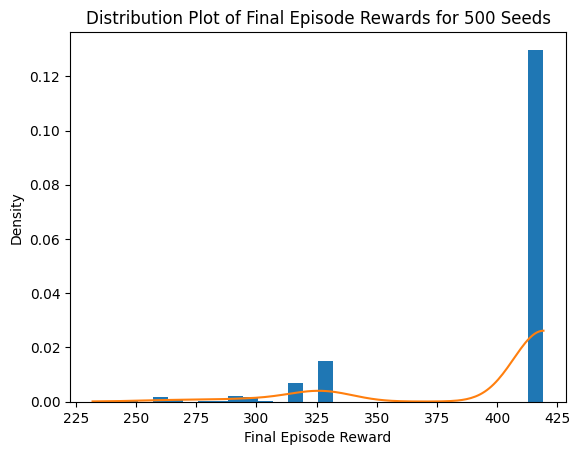

In [4]:
# ============================================================
# EVALUATE MODEL ACROSS 100 DIFFERENT SEEDS
# ============================================================

import numpy as np
from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.transformer_policy import MaskableTransformerPolicy

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
            "vessel_shape": (4, 4, 4),
            "yard_shape": (4, 4, 4),
            "num_containers": 64,
            "group_num": 4,
            "group_placement": "random",
            "observation_type": "stack_features",
            "reward_norm": False
            }

# ============================================================
# LOAD MODEL
# ============================================================

model = MaskablePPO.load("models/ppo_stack_medium_clip_parallelenv_transsmallnet_lr1e4_best",
                         custom_objects={"policy_class": MaskableTransformerPolicy}
                         )

print("=" * 70)
print("EVALUATING MODEL ACROSS 500 SEEDS")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

steps = config_dict["num_containers"]
num_seeds = 500
all_rewards_per_Step = np.zeros((num_seeds, steps))
all_rewards = []

for seed in range(num_seeds):
    
    # Create eval env
    eval_env = StackEnv(config=config_dict, render_mode=None)
    eval_env = ActionMasker(eval_env, mask_fn)
    
    # Reset with specific seed
    obs, info = eval_env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    step_count = 0
    
    # Run episode
    while not (terminated or truncated) and step_count < 120:
        action, _ = model.predict(
            obs,
            deterministic=True,
            action_masks=get_action_masks(eval_env)
        )
        
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        step_count += 1
        all_rewards_per_Step[seed, step_count - 1] = reward
        
    
    all_rewards.append(total_reward)
    eval_env.close()
    
    # Progress update every 50 seeds
    if (seed + 1) % 50 == 0:
        print(f"Completed {seed + 1}/{num_seeds} seeds...")

# ============================================================
# COMPUTE STATISTICS
# ============================================================

all_rewards = np.array(all_rewards)
mean_reward = np.mean(all_rewards)
std_reward = np.std(all_rewards)
min_reward = np.min(all_rewards)
max_reward = np.max(all_rewards)

percent_of_seeds_with_max_reward = np.sum(all_rewards > 416) / num_seeds * 100

print(f"Seed with highest reward: {np.argmax(all_rewards)}")
print(f"Seed with lowest reward: {np.argmin(all_rewards)}")


print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward:.4f}")
print(f"Std Reward:  {std_reward:.4f}")
print(f"Min Reward:  {min_reward:.4f}")
print(f"Max Reward:  {max_reward:.4f}")
print(f"Percentage of seeds that achieved max reward: {percent_of_seeds_with_max_reward:.2f}%")
print("=" * 70)



# Density plots with 
plt.figure()

# histogram
plt.hist(all_rewards, bins=30, density=True)

# density curve
density = gaussian_kde(all_rewards)
xs = np.linspace(all_rewards.min(), all_rewards.max(), 200)
plt.plot(xs, density(xs))

plt.xlabel("Final Episode Reward")
plt.ylabel("Density")
plt.title("Distribution Plot of Final Episode Rewards for 500 Seeds")
plt.show()

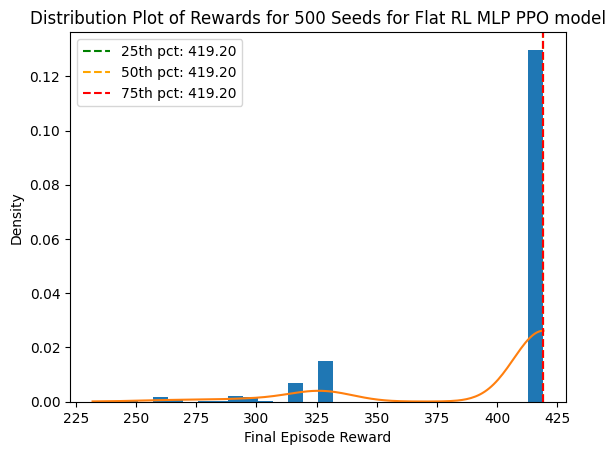

In [5]:
# Density plots with 
plt.figure()

# histogram
plt.hist(all_rewards, bins=30, density=True)

# density curve
density = gaussian_kde(all_rewards)
xs = np.linspace(all_rewards.min(), all_rewards.max(), 200)
plt.plot(xs, density(xs))

# Percentile lines
p25, p50, p75 = np.percentile(all_rewards, [25, 50, 75])
for p, label, color in [(p25, "25th", "green"), (p50, "50th", "orange"), (p75, "75th", "red")]:
    plt.axvline(p, color=color, linestyle="--", label=f"{label} pct: {p:.2f}")

plt.legend()
plt.xlabel("Final Episode Reward")
plt.ylabel("Density")
plt.title("Distribution Plot of Rewards for 500 Seeds for Flat RL MLP PPO model")
plt.show()

In [8]:
# ============================================================
# LOAD SAVED MODEL + INTERACTIVE VISUAL EVALUATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.transformer_policy import MaskableTransformerPolicy
from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
    "vessel_shape": (4, 4, 4),
    "yard_shape": (4, 4, 4),
    "num_containers": 64,
    "group_num": 4,
    "group_placement": "random",
    "observation_type": "stack_features",
    "reward_norm": False
}

# ============================================================
# CREATE ENV + LOAD MODEL
# ============================================================

eval_env = StackEnv(config=config_dict, render_mode="rgb_array")
eval_env = ActionMasker(eval_env, mask_fn)

model = MaskablePPO.load(
    "models/ppo_stack_medium_clip_parallelenv_transsmallnet_lr1e4_best",
    custom_objects={"policy_class": MaskableTransformerPolicy}
)

# ============================================================
# RUN EPISODE & COLLECT FRAMES
# ============================================================

obs, info = eval_env.reset(seed=396)
terminated = False
truncated = False
total_reward = 0.0
step_count = 0

frames = []  # list of (img, step, action, reward, cumulative_reward)

while not (terminated or truncated) and step_count < 120:
    action, _ = model.predict(
        obs, deterministic=True, action_masks=get_action_masks(eval_env)
    )
    obs, reward, terminated, truncated, info = eval_env.step(action)
    total_reward += reward
    step_count += 1

    img = eval_env.render()
    if img is not None:
        frames.append((img, step_count, int(action), reward, total_reward))

eval_env.close()

print(f"Episode finished: {len(frames)} frames | Total Reward: {total_reward:.4f}")

# ============================================================
# INTERACTIVE VIEWER WIDGET
# ============================================================

slider = widgets.IntSlider(
    value=0, min=0, max=len(frames) - 1, step=1,
    description="Step:", continuous_update=False,
    layout=widgets.Layout(width="60%")
)
prev_btn = widgets.Button(description="◀ Prev", layout=widgets.Layout(width="80px"))
next_btn = widgets.Button(description="Next ▶", layout=widgets.Layout(width="80px"))
info_label = widgets.HTML()
out = widgets.Output()

def show_frame(idx):
    img, step, action, reward, cum_reward = frames[idx]
    info_label.value = (
        f"<b>Step {step}/{len(frames)}</b> &nbsp;|&nbsp; "
        f"Action: {action} &nbsp;|&nbsp; "
        f"Reward: {reward:.4f} &nbsp;|&nbsp; "
        f"Cumulative: {cum_reward:.4f}"
    )
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.imshow(img)
        ax.set_title(
            f"Step {step} | Action: {action} | "
            f"Reward: {reward:.4f} | Total: {cum_reward:.4f}"
        )
        ax.axis("off")
        fig.tight_layout()
        plt.show()

def on_slider_change(change):
    show_frame(change["new"])

def on_prev(b):
    slider.value = max(0, slider.value - 1)

def on_next(b):
    slider.value = min(len(frames) - 1, slider.value + 1)

slider.observe(on_slider_change, names="value")
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

ui = widgets.VBox([
    info_label,
    widgets.HBox([prev_btn, slider, next_btn]),
    out
])

display(ui)
show_frame(0)

Episode finished: 64 frames | Total Reward: 203.2000


Flat RL eval

EVALUATING MODEL ACROSS 500 SEEDS
Completed 50/500 seeds...
Completed 100/500 seeds...
Completed 150/500 seeds...
Completed 200/500 seeds...
Completed 250/500 seeds...
Completed 300/500 seeds...
Completed 350/500 seeds...
Completed 400/500 seeds...
Completed 450/500 seeds...
Completed 500/500 seeds...
Seed with highest reward: 0
Seed with lowest reward: 409

EVALUATION RESULTS
Mean Reward: 407.7936
Std Reward:  26.9057
Min Reward:  290.4000
Max Reward:  419.2000
Percentage of seeds that achieved max reward: 83.20%


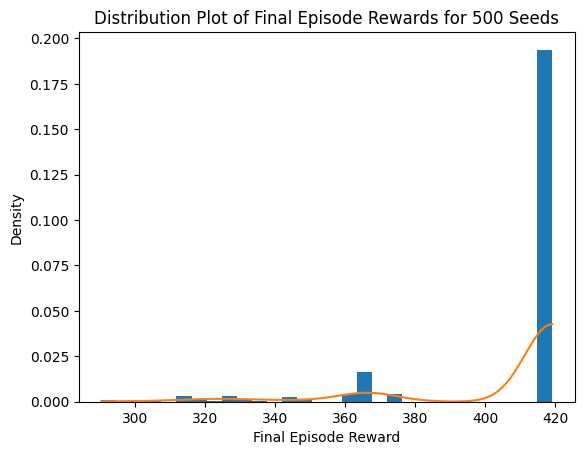

In [1]:
# ============================================================
# EVALUATE MODEL ACROSS 100 DIFFERENT SEEDS
# ============================================================

import numpy as np
from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
            "vessel_shape": (4, 4, 4),
            "yard_shape": (4, 4, 4),
            "num_containers": 64,
            "group_num": 4,
            "group_placement": "random",
            "observation_type": "stack_features",
            "reward_norm": False
            }

# ============================================================
# LOAD MODEL
# ============================================================

model = MaskablePPO.load("models/ppo_stack_medium_clip_parallelenv_best")


print("=" * 70)
print("EVALUATING MODEL ACROSS 500 SEEDS")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

steps = config_dict["num_containers"]
num_seeds = 500
all_rewards_per_Step = np.zeros((num_seeds, steps))
all_rewards = []

for seed in range(num_seeds):
    
    # Create eval env
    eval_env = StackEnv(config=config_dict, render_mode=None)
    eval_env = ActionMasker(eval_env, mask_fn)
    
    # Reset with specific seed
    obs, info = eval_env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    step_count = 0
    
    # Run episode
    while not (terminated or truncated) and step_count < 120:
        action, _ = model.predict(
            obs,
            deterministic=True,
            action_masks=get_action_masks(eval_env)
        )
        
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        step_count += 1
        all_rewards_per_Step[seed, step_count - 1] = reward
        
    
    all_rewards.append(total_reward)
    eval_env.close()
    
    # Progress update every 50 seeds
    if (seed + 1) % 50 == 0:
        print(f"Completed {seed + 1}/{num_seeds} seeds...")

# ============================================================
# COMPUTE STATISTICS
# ============================================================

all_rewards = np.array(all_rewards)
mean_reward = np.mean(all_rewards)
std_reward = np.std(all_rewards)
min_reward = np.min(all_rewards)
max_reward = np.max(all_rewards)

percent_of_seeds_with_max_reward = np.sum(all_rewards > 416) / num_seeds * 100

print(f"Seed with highest reward: {np.argmax(all_rewards)}")
print(f"Seed with lowest reward: {np.argmin(all_rewards)}")


print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward:.4f}")
print(f"Std Reward:  {std_reward:.4f}")
print(f"Min Reward:  {min_reward:.4f}")
print(f"Max Reward:  {max_reward:.4f}")
print(f"Percentage of seeds that achieved max reward: {percent_of_seeds_with_max_reward:.2f}%")
print("=" * 70)



# Density plots with 
plt.figure()

# histogram
plt.hist(all_rewards, bins=30, density=True)

# density curve
density = gaussian_kde(all_rewards)
xs = np.linspace(all_rewards.min(), all_rewards.max(), 200)
plt.plot(xs, density(xs))

plt.xlabel("Final Episode Reward")
plt.ylabel("Density")
plt.title("Distribution Plot of Final Episode Rewards for 500 Seeds")
plt.show()

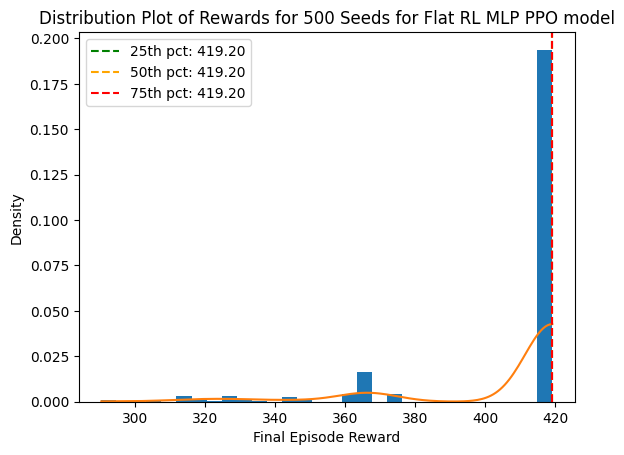

In [2]:
# Density plots with 
plt.figure()

# histogram
plt.hist(all_rewards, bins=30, density=True)

# density curve
density = gaussian_kde(all_rewards)
xs = np.linspace(all_rewards.min(), all_rewards.max(), 200)
plt.plot(xs, density(xs))

# Percentile lines
p25, p50, p75 = np.percentile(all_rewards, [25, 50, 75])
for p, label, color in [(p25, "25th", "green"), (p50, "50th", "orange"), (p75, "75th", "red")]:
    plt.axvline(p, color=color, linestyle="--", label=f"{label} pct: {p:.2f}")

plt.legend()
plt.xlabel("Final Episode Reward")
plt.ylabel("Density")
plt.title("Distribution Plot of Rewards for 500 Seeds for Flat RL MLP PPO model")
plt.show()

In [10]:
# ============================================================
# LOAD SAVED MODEL + INTERACTIVE VISUAL EVALUATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.transformer_policy import MaskableTransformerPolicy
from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
    "vessel_shape": (4, 4, 4),
    "yard_shape": (4, 4, 4),
    "num_containers": 64,
    "group_num": 4,
    "group_placement": "random",
    "observation_type": "stack_features",
    "reward_norm": False
}

# ============================================================
# CREATE ENV + LOAD MODEL
# ============================================================

eval_env = StackEnv(config=config_dict, render_mode="rgb_array")
eval_env = ActionMasker(eval_env, mask_fn)

model = MaskablePPO.load("models/ppo_stack_medium_clip_parallelenv_best")

# ============================================================
# RUN EPISODE & COLLECT FRAMES
# ============================================================

obs, info = eval_env.reset(seed=409)
terminated = False
truncated = False
total_reward = 0.0
step_count = 0

frames = []  # list of (img, step, action, reward, cumulative_reward)

while not (terminated or truncated) and step_count < 120:
    action, _ = model.predict(
        obs, deterministic=True, action_masks=get_action_masks(eval_env)
    )
    obs, reward, terminated, truncated, info = eval_env.step(action)
    total_reward += reward
    step_count += 1

    img = eval_env.render()
    if img is not None:
        frames.append((img, step_count, int(action), reward, total_reward))

eval_env.close()

print(f"Episode finished: {len(frames)} frames | Total Reward: {total_reward:.4f}")

# ============================================================
# INTERACTIVE VIEWER WIDGET
# ============================================================

slider = widgets.IntSlider(
    value=0, min=0, max=len(frames) - 1, step=1,
    description="Step:", continuous_update=False,
    layout=widgets.Layout(width="60%")
)
prev_btn = widgets.Button(description="◀ Prev", layout=widgets.Layout(width="80px"))
next_btn = widgets.Button(description="Next ▶", layout=widgets.Layout(width="80px"))
info_label = widgets.HTML()
out = widgets.Output()

def show_frame(idx):
    img, step, action, reward, cum_reward = frames[idx]
    info_label.value = (
        f"<b>Step {step}/{len(frames)}</b> &nbsp;|&nbsp; "
        f"Action: {action} &nbsp;|&nbsp; "
        f"Reward: {reward:.4f} &nbsp;|&nbsp; "
        f"Cumulative: {cum_reward:.4f}"
    )
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.imshow(img)
        ax.set_title(
            f"Step {step} | Action: {action} | "
            f"Reward: {reward:.4f} | Total: {cum_reward:.4f}"
        )
        ax.axis("off")
        fig.tight_layout()
        plt.show()

def on_slider_change(change):
    show_frame(change["new"])

def on_prev(b):
    slider.value = max(0, slider.value - 1)

def on_next(b):
    slider.value = min(len(frames) - 1, slider.value + 1)

slider.observe(on_slider_change, names="value")
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

ui = widgets.VBox([
    info_label,
    widgets.HBox([prev_btn, slider, next_btn]),
    out
])

display(ui)
show_frame(0)

Episode finished: 64 frames | Total Reward: 290.4000


Big yard testing

EVALUATING MODEL ACROSS 500 SEEDS
Completed 50/500 seeds...
Completed 100/500 seeds...
Completed 150/500 seeds...
Completed 200/500 seeds...
Completed 250/500 seeds...
Completed 300/500 seeds...
Completed 350/500 seeds...
Completed 400/500 seeds...
Completed 450/500 seeds...
Completed 500/500 seeds...
Seed with highest reward: 203
Seed with lowest reward: 39

EVALUATION RESULTS
Mean Reward: 702.2760
Std Reward:  124.5154
Min Reward:  219.2000
Max Reward:  1178.8000
Percentage of seeds that achieved max reward: 98.60%


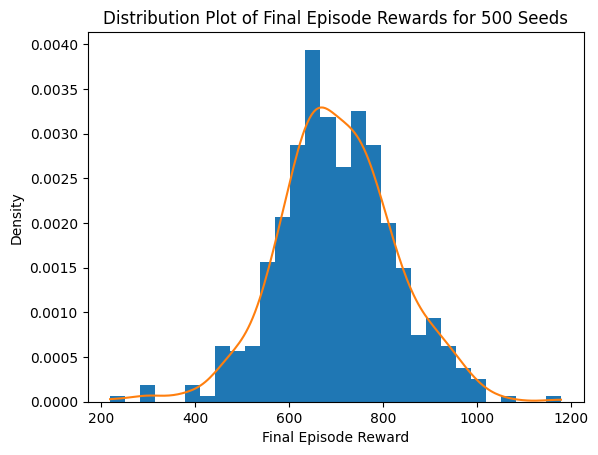

In [4]:
# ============================================================
# EVALUATE MODEL ACROSS 100 DIFFERENT SEEDS
# ============================================================

import numpy as np
from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde


from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
            "vessel_shape": (6, 6, 5),
            "yard_shape": (6, 6, 5),
            "num_containers": 180,
            "group_num": 6,
            "group_placement": "random",
            "observation_type": "stack_features",
            "reward_norm": False
            }

# ============================================================
# LOAD MODEL
# ============================================================

model = MaskablePPO.load("models/ppo_stack_large_clip_parallelenv_transsmallnet_lr1e4_best")


print("=" * 70)
print("EVALUATING MODEL ACROSS 500 SEEDS")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

steps = config_dict["num_containers"]
num_seeds = 500
all_rewards_per_Step = np.zeros((num_seeds, steps))
all_rewards = []

for seed in range(num_seeds):
    
    # Create eval env
    eval_env = StackEnv(config=config_dict, render_mode=None)
    eval_env = ActionMasker(eval_env, mask_fn)
    
    # Reset with specific seed
    obs, info = eval_env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    step_count = 0
    
    # Run episode
    while not (terminated or truncated) and step_count < 200:
        action, _ = model.predict(
            obs,
            deterministic=True,
            action_masks=get_action_masks(eval_env)
        )
        
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        step_count += 1
        all_rewards_per_Step[seed, step_count - 1] = reward
        
    
    all_rewards.append(total_reward)
    eval_env.close()
    
    # Progress update every 50 seeds
    if (seed + 1) % 50 == 0:
        print(f"Completed {seed + 1}/{num_seeds} seeds...")

# ============================================================
# COMPUTE STATISTICS
# ============================================================

all_rewards = np.array(all_rewards)
mean_reward = np.mean(all_rewards)
std_reward = np.std(all_rewards)
min_reward = np.min(all_rewards)
max_reward = np.max(all_rewards)

percent_of_seeds_with_max_reward = np.sum(all_rewards > 416) / num_seeds * 100

print(f"Seed with highest reward: {np.argmax(all_rewards)}")
print(f"Seed with lowest reward: {np.argmin(all_rewards)}")


print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward:.4f}")
print(f"Std Reward:  {std_reward:.4f}")
print(f"Min Reward:  {min_reward:.4f}")
print(f"Max Reward:  {max_reward:.4f}")
print(f"Percentage of seeds that achieved max reward: {percent_of_seeds_with_max_reward:.2f}%")
print("=" * 70)



# Density plots with 
plt.figure()

# histogram
plt.hist(all_rewards, bins=30, density=True)

# density curve
density = gaussian_kde(all_rewards)
xs = np.linspace(all_rewards.min(), all_rewards.max(), 200)
plt.plot(xs, density(xs))

plt.xlabel("Final Episode Reward")
plt.ylabel("Density")
plt.title("Distribution Plot of Final Episode Rewards for 500 Seeds")
plt.show()

In [17]:
# ============================================================
# LOAD SAVED MODEL + INTERACTIVE VISUAL EVALUATION
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.transformer_policy import MaskableTransformerPolicy
from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
    "vessel_shape": (6, 6, 5),
    "yard_shape": (6, 6, 5),
    "num_containers": 180,
    "group_num": 6,
    "group_placement": "random",
    "observation_type": "stack_features",
    "reward_norm": False
}

# ============================================================
# CREATE ENV + LOAD MODEL
# ============================================================

eval_env = StackEnv(config=config_dict, render_mode="rgb_array")
eval_env = ActionMasker(eval_env, mask_fn)

model = MaskablePPO.load("models/ppo_stack_large_clip_parallelenv_transsmallnet_lr1e4_best")

# ============================================================
# RUN EPISODE & COLLECT FRAMES
# ============================================================

obs, info = eval_env.reset(seed=39)
terminated = False
truncated = False
total_reward = 0.0
step_count = 0

frames = []  # list of (img, step, action, reward, cumulative_reward)

while not (terminated or truncated) and step_count < 200:
    action, _ = model.predict(
        obs, deterministic=True, action_masks=get_action_masks(eval_env)
    )
    obs, reward, terminated, truncated, info = eval_env.step(action)
    total_reward += reward
    step_count += 1

    img = eval_env.render()
    if img is not None:
        frames.append((img, step_count, int(action), reward, total_reward))

eval_env.close()

print(f"Episode finished: {len(frames)} frames | Total Reward: {total_reward:.4f}")

# ============================================================
# INTERACTIVE VIEWER WIDGET
# ============================================================

slider = widgets.IntSlider(
    value=0, min=0, max=len(frames) - 1, step=1,
    description="Step:", continuous_update=False,
    layout=widgets.Layout(width="60%")
)
prev_btn = widgets.Button(description="◀ Prev", layout=widgets.Layout(width="80px"))
next_btn = widgets.Button(description="Next ▶", layout=widgets.Layout(width="80px"))
info_label = widgets.HTML()
out = widgets.Output()

def show_frame(idx):
    img, step, action, reward, cum_reward = frames[idx]
    info_label.value = (
        f"<b>Step {step}/{len(frames)}</b> &nbsp;|&nbsp; "
        f"Action: {action} &nbsp;|&nbsp; "
        f"Reward: {reward:.4f} &nbsp;|&nbsp; "
        f"Cumulative: {cum_reward:.4f}"
    )
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.imshow(img)
        ax.set_title(
            f"Step {step} | Action: {action} | "
            f"Reward: {reward:.4f} | Total: {cum_reward:.4f}"
        )
        ax.axis("off")
        fig.tight_layout()
        plt.show()

def on_slider_change(change):
    show_frame(change["new"])

def on_prev(b):
    slider.value = max(0, slider.value - 1)

def on_next(b):
    slider.value = min(len(frames) - 1, slider.value + 1)

slider.observe(on_slider_change, names="value")
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

ui = widgets.VBox([
    info_label,
    widgets.HBox([prev_btn, slider, next_btn]),
    out
])

display(ui)
show_frame(0)

Episode finished: 180 frames | Total Reward: 230.0000


HRL Full Test Medium Yard

EVALUATING FULLY HIERARCHICAL RL MODEL ACROSS 500 SEEDS
Completed 50/500 seeds...
Completed 100/500 seeds...
Completed 150/500 seeds...
Completed 200/500 seeds...
Completed 250/500 seeds...
Completed 300/500 seeds...
Completed 350/500 seeds...
Completed 400/500 seeds...
Completed 450/500 seeds...
Completed 500/500 seeds...
Seed with highest reward: 1
Seed with lowest reward:  451

EVALUATION RESULTS
Mean Reward: 422.2944
Std Reward:  2.3589
Min Reward:  369.6000
Max Reward:  422.4000
% seeds achieving max reward: 100.00%


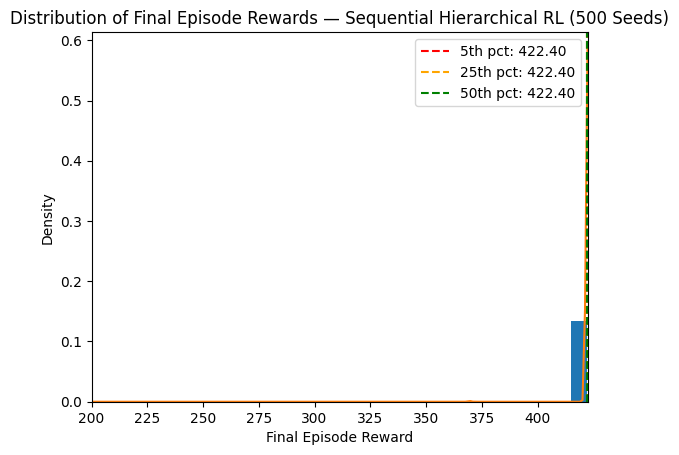

In [1]:
# ============================================================
# EVALUATE FULLY HIERARCHICAL MODEL (RL high-level + RL low-level)
# ACROSS 500 DIFFERENT SEEDS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
#from models.transformer_policy import MaskableTransformerPolicy
from models.transformer_bay_policy import MaskableBayTransformerPolicy  # ← correct class


from envs.hierarchical_envs.hierarchical_high_level_env import HierarchicalHighLevelEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
    "vessel_shape": (4, 4, 4),
    "yard_shape": (4, 4, 4),
    "num_containers": 64,
    "group_num": 4,
    "group_placement": "random",
    "observation_type": "stack_features",
    "reward_norm": False,
    "stack_fill_penalty": True
}

LOW_LEVEL_MODEL_PATH  = "models/hierarchical_low_level/ppo_low_level_pointer_medium_best"
HIGH_LEVEL_MODEL_PATH = "models/hierarchical_high_level/ppo_high_level_pointer_medium_best"

# ============================================================
# LOAD HIGH-LEVEL MODEL
# ============================================================

hl_model = MaskablePPO.load(
    HIGH_LEVEL_MODEL_PATH,
    custom_objects={"policy_class": MaskableBayTransformerPolicy},
)

print("=" * 70)
print("EVALUATING FULLY HIERARCHICAL RL MODEL ACROSS 500 SEEDS")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

steps = config_dict["num_containers"]
num_seeds = 500
all_rewards_per_step = np.zeros((num_seeds, steps))
all_rewards = []

for seed in range(num_seeds):

    # HierarchicalHighLevelEnv internally loads the frozen RL low-level agent
    eval_env = HierarchicalHighLevelEnv(
        config=config_dict,
        low_level_model_path=LOW_LEVEL_MODEL_PATH,
        render_mode=None,
    )
    eval_env = ActionMasker(eval_env, mask_fn)

    obs, info = eval_env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    step_count = 0

    while not (terminated or truncated) and step_count < 200:
        action, _ = hl_model.predict(
            obs,
            deterministic=True,
            action_masks=get_action_masks(eval_env),
        )
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        step_count += 1
        all_rewards_per_step[seed, step_count - 1] = reward

    all_rewards.append(total_reward)
    eval_env.close()

    if (seed + 1) % 50 == 0:
        print(f"Completed {seed + 1}/{num_seeds} seeds...")

# ============================================================
# COMPUTE STATISTICS
# ============================================================

all_rewards = np.array(all_rewards)
mean_reward = np.mean(all_rewards)
std_reward  = np.std(all_rewards)
min_reward  = np.min(all_rewards)
max_reward  = np.max(all_rewards)

percent_max = np.sum(all_rewards > 110) / num_seeds * 100

print(f"Seed with highest reward: {np.argmax(all_rewards)}")
print(f"Seed with lowest reward:  {np.argmin(all_rewards)}")
print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward:.4f}")
print(f"Std Reward:  {std_reward:.4f}")
print(f"Min Reward:  {min_reward:.4f}")
print(f"Max Reward:  {max_reward:.4f}")
print(f"% seeds achieving max reward: {percent_max:.2f}%")
print("=" * 70)

# ============================================================
# DENSITY PLOT
# ============================================================

# ============================================================
# DENSITY PLOT
# ============================================================

p5, p25, p50 = np.percentile(all_rewards, [5, 25, 50])

plt.figure()
plt.hist(all_rewards, bins=30, density=True, range=(200, all_rewards.max()))
density = gaussian_kde(all_rewards)
xs = np.linspace(200, all_rewards.max(), 200)
plt.plot(xs, density(xs))

for p, label, color in [(p5, "5th", "red"), (p25, "25th", "orange"), (p50, "50th", "green")]:
    plt.axvline(p, color=color, linestyle="--", label=f"{label} pct: {p:.2f}")

plt.xlim(200, all_rewards.max())
plt.legend()
plt.xlabel("Final Episode Reward")
plt.ylabel("Density")
plt.title("Distribution of Final Episode Rewards — Sequential Hierarchical RL (500 Seeds)")
plt.show()

In [ ]:
# ============================================================
# LOAD FULLY HIERARCHICAL MODEL + INTERACTIVE VISUAL EVALUATION
# (RL high-level + RL low-level)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.transformer_bay_policy import MaskableBayTransformerPolicy
from envs.hierarchical_envs.hierarchical_high_level_env import HierarchicalHighLevelEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
    "vessel_shape": (4, 4, 4),
    "yard_shape": (4, 4, 4),
    "num_containers": 64,
    "group_num": 4,
    "group_placement": "random",
    "observation_type": "stack_features",
    "reward_norm": False,
    "stack_fill_penalty": True
}

LOW_LEVEL_MODEL_PATH  = "models/hierarchical_low_level/ppo_low_level_pointer_medium_best"
HIGH_LEVEL_MODEL_PATH = "models/hierarchical_high_level/ppo_high_level_pointer_medium_best"

# ============================================================
# CREATE ENV + LOAD MODEL
# ============================================================

eval_env = HierarchicalHighLevelEnv(
    config=config_dict,
    low_level_model_path=LOW_LEVEL_MODEL_PATH,
    render_mode="rgb_array",
)
eval_env = ActionMasker(eval_env, mask_fn)

hl_model = MaskablePPO.load(
    HIGH_LEVEL_MODEL_PATH,
    custom_objects={"policy_class": MaskableBayTransformerPolicy},
)

# ============================================================
# RUN EPISODE & COLLECT FRAMES
# ============================================================

obs, info = eval_env.reset(seed=1)
terminated = False
truncated = False
total_reward = 0.0
step_count = 0

frames = []  # list of (img, step, bay_action, reward, cumulative_reward)

while not (terminated or truncated) and step_count < 200:
    action, _ = hl_model.predict(
        obs, deterministic=True, action_masks=get_action_masks(eval_env)
    )
    obs, reward, terminated, truncated, info = eval_env.step(action)
    total_reward += reward
    step_count += 1

    img = eval_env.render()
    if img is not None:
        frames.append((img, step_count, int(action), reward, total_reward, info.get("selected_bay")))

eval_env.close()

print(f"Episode finished: {len(frames)} frames | Total Reward: {total_reward:.4f}")

# ============================================================
# INTERACTIVE VIEWER WIDGET
# ============================================================

slider = widgets.IntSlider(
    value=0, min=0, max=len(frames) - 1, step=1,
    description="Step:", continuous_update=False,
    layout=widgets.Layout(width="60%")
)
prev_btn = widgets.Button(description="◀ Prev", layout=widgets.Layout(width="80px"))
next_btn = widgets.Button(description="Next ▶", layout=widgets.Layout(width="80px"))
info_label = widgets.HTML()
out = widgets.Output()

def show_frame(idx):
    img, step, action, reward, cum_reward, selected_bay = frames[idx]
    info_label.value = (
        f"<b>Step {step}/{len(frames)}</b> &nbsp;|&nbsp; "
        f"HL Action (bay idx): {action} &nbsp;|&nbsp; "
        f"Bay: {selected_bay} &nbsp;|&nbsp; "
        f"Reward: {reward:.4f} &nbsp;|&nbsp; "
        f"Cumulative: {cum_reward:.4f}"
    )
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.imshow(img)
        ax.set_title(
            f"Step {step} | HL Action: {action} | Bay: {selected_bay} | "
            f"Reward: {reward:.4f} | Total: {cum_reward:.4f}"
        )
        ax.axis("off")
        fig.tight_layout()
        plt.show()

def on_slider_change(change):
    show_frame(change["new"])

def on_prev(b):
    slider.value = max(0, slider.value - 1)

def on_next(b):
    slider.value = min(len(frames) - 1, slider.value + 1)

slider.observe(on_slider_change, names="value")
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

ui = widgets.VBox([
    info_label,
    widgets.HBox([prev_btn, slider, next_btn]),
    out
])

display(ui)
show_frame(0)

c:\Users\Aritra\rl intern\github\toy_sim\stowage_env\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Episode finished: 64 frames | Total Reward: 422.4000


HRL Full Testing

EVALUATING FULLY HIERARCHICAL RL MODEL ACROSS 500 SEEDS
Completed 50/500 seeds...
Completed 100/500 seeds...
Completed 150/500 seeds...
Completed 200/500 seeds...
Completed 250/500 seeds...
Completed 300/500 seeds...
Completed 350/500 seeds...
Completed 400/500 seeds...
Completed 450/500 seeds...
Completed 500/500 seeds...
Seed with highest reward: 2
Seed with lowest reward:  1

EVALUATION RESULTS
Mean Reward: 113.4000
Std Reward:  0.0000
Min Reward:  113.4000
Max Reward:  113.4000
% seeds achieving max reward: 100.00%


ValueError: Too many bins for data range. Cannot create 30 finite-sized bins.

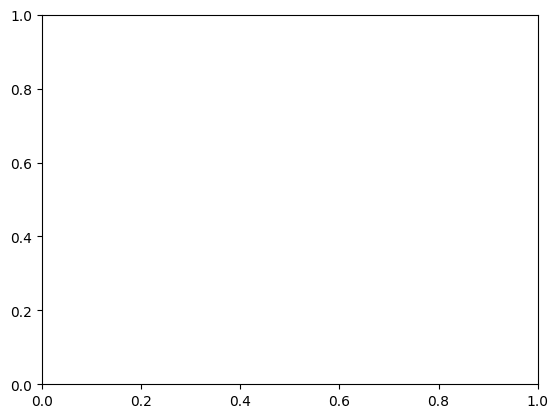

In [2]:
# ============================================================
# EVALUATE FULLY HIERARCHICAL MODEL (RL high-level + RL low-level)
# ACROSS 500 DIFFERENT SEEDS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
#from models.transformer_policy import MaskableTransformerPolicy
from models.transformer_bay_policy import MaskableBayTransformerPolicy  # ← correct class


from envs.hierarchical_envs.hierarchical_high_level_env import HierarchicalHighLevelEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
    "vessel_shape": (3, 3, 3),
    "yard_shape": (3, 3, 3),
    "num_containers": 27,
    "group_num": 3,
    "group_placement": "random",
    "observation_type": "stack_features",
    "reward_norm": False,
    "stack_fill_penalty": True
}

LOW_LEVEL_MODEL_PATH  = "models/hierarchical_low_level/ppo_low_level_pointer_small_best"
HIGH_LEVEL_MODEL_PATH = "models/hierarchical_high_level/ppo_high_level_pointer_small_best"

# ============================================================
# LOAD HIGH-LEVEL MODEL
# ============================================================

hl_model = MaskablePPO.load(
    HIGH_LEVEL_MODEL_PATH,
    custom_objects={"policy_class": MaskableBayTransformerPolicy},
)

print("=" * 70)
print("EVALUATING FULLY HIERARCHICAL RL MODEL ACROSS 500 SEEDS")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

steps = config_dict["num_containers"]
num_seeds = 500
all_rewards_per_step = np.zeros((num_seeds, steps))
all_rewards = []

for seed in range(num_seeds):

    # HierarchicalHighLevelEnv internally loads the frozen RL low-level agent
    eval_env = HierarchicalHighLevelEnv(
        config=config_dict,
        low_level_model_path=LOW_LEVEL_MODEL_PATH,
        render_mode=None,
    )
    eval_env = ActionMasker(eval_env, mask_fn)

    obs, info = eval_env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    step_count = 0

    while not (terminated or truncated) and step_count < 200:
        action, _ = hl_model.predict(
            obs,
            deterministic=True,
            action_masks=get_action_masks(eval_env),
        )
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        step_count += 1
        all_rewards_per_step[seed, step_count - 1] = reward

    all_rewards.append(total_reward)
    eval_env.close()

    if (seed + 1) % 50 == 0:
        print(f"Completed {seed + 1}/{num_seeds} seeds...")

# ============================================================
# COMPUTE STATISTICS
# ============================================================

all_rewards = np.array(all_rewards)
mean_reward = np.mean(all_rewards)
std_reward  = np.std(all_rewards)
min_reward  = np.min(all_rewards)
max_reward  = np.max(all_rewards)

percent_max = np.sum(all_rewards > 110) / num_seeds * 100

print(f"Seed with highest reward: {np.argmax(all_rewards)}")
print(f"Seed with lowest reward:  {np.argmin(all_rewards)}")
print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward:.4f}")
print(f"Std Reward:  {std_reward:.4f}")
print(f"Min Reward:  {min_reward:.4f}")
print(f"Max Reward:  {max_reward:.4f}")
print(f"% seeds achieving max reward: {percent_max:.2f}%")
print("=" * 70)

# ============================================================
# DENSITY PLOT
# ============================================================

plt.figure()
plt.hist(all_rewards, bins=1, density=True)
density = gaussian_kde(all_rewards)
xs = np.linspace(all_rewards.min(), all_rewards.max(), 200)
plt.plot(xs, density(xs))
plt.xlabel("Final Episode Reward")
plt.ylabel("Density")
plt.title("Distribution of Rewards — Fully Hierarchical RL (500 Seeds)")
plt.show()

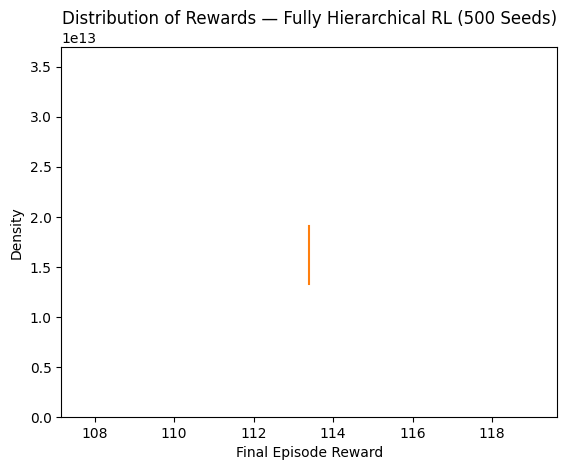

In [6]:
plt.figure()
plt.hist(all_rewards, bins=1, density=True)
density = gaussian_kde(all_rewards)
xs = np.linspace(all_rewards.min(), all_rewards.max(), 200)
plt.plot(xs, density(xs))
plt.xlabel("Final Episode Reward")
plt.ylabel("Density")
plt.title("Distribution of Rewards — Fully Hierarchical RL (500 Seeds)")
plt.show()

In [7]:
# ============================================================
# LOAD FULLY HIERARCHICAL MODEL + INTERACTIVE VISUAL EVALUATION
# (RL high-level + RL low-level)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.transformer_bay_policy import MaskableBayTransformerPolicy
from envs.hierarchical_envs.hierarchical_high_level_env import HierarchicalHighLevelEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
    "vessel_shape": (3, 3, 3),
    "yard_shape": (3, 3, 3),
    "num_containers": 27,
    "group_num": 3,
    "group_placement": "random",
    "observation_type": "stack_features",
    "reward_norm": False,
    "stack_fill_penalty": True
}

LOW_LEVEL_MODEL_PATH  = "models/hierarchical_low_level/ppo_low_level_pointer_small_best"
HIGH_LEVEL_MODEL_PATH = "models/hierarchical_high_level/ppo_high_level_pointer_small_best"

# ============================================================
# CREATE ENV + LOAD MODEL
# ============================================================

eval_env = HierarchicalHighLevelEnv(
    config=config_dict,
    low_level_model_path=LOW_LEVEL_MODEL_PATH,
    render_mode="rgb_array",
)
eval_env = ActionMasker(eval_env, mask_fn)

hl_model = MaskablePPO.load(
    HIGH_LEVEL_MODEL_PATH,
    custom_objects={"policy_class": MaskableBayTransformerPolicy},
)

# ============================================================
# RUN EPISODE & COLLECT FRAMES
# ============================================================

obs, info = eval_env.reset(seed=50)
terminated = False
truncated = False
total_reward = 0.0
step_count = 0

frames = []  # list of (img, step, bay_action, reward, cumulative_reward)

while not (terminated or truncated) and step_count < 200:
    action, _ = hl_model.predict(
        obs, deterministic=True, action_masks=get_action_masks(eval_env)
    )
    obs, reward, terminated, truncated, info = eval_env.step(action)
    total_reward += reward
    step_count += 1

    img = eval_env.render()
    if img is not None:
        frames.append((img, step_count, int(action), reward, total_reward, info.get("selected_bay")))

eval_env.close()

print(f"Episode finished: {len(frames)} frames | Total Reward: {total_reward:.4f}")

# ============================================================
# INTERACTIVE VIEWER WIDGET
# ============================================================

slider = widgets.IntSlider(
    value=0, min=0, max=len(frames) - 1, step=1,
    description="Step:", continuous_update=False,
    layout=widgets.Layout(width="60%")
)
prev_btn = widgets.Button(description="◀ Prev", layout=widgets.Layout(width="80px"))
next_btn = widgets.Button(description="Next ▶", layout=widgets.Layout(width="80px"))
info_label = widgets.HTML()
out = widgets.Output()

def show_frame(idx):
    img, step, action, reward, cum_reward, selected_bay = frames[idx]
    info_label.value = (
        f"<b>Step {step}/{len(frames)}</b> &nbsp;|&nbsp; "
        f"HL Action (bay idx): {action} &nbsp;|&nbsp; "
        f"Bay: {selected_bay} &nbsp;|&nbsp; "
        f"Reward: {reward:.4f} &nbsp;|&nbsp; "
        f"Cumulative: {cum_reward:.4f}"
    )
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.imshow(img)
        ax.set_title(
            f"Step {step} | HL Action: {action} | Bay: {selected_bay} | "
            f"Reward: {reward:.4f} | Total: {cum_reward:.4f}"
        )
        ax.axis("off")
        fig.tight_layout()
        plt.show()

def on_slider_change(change):
    show_frame(change["new"])

def on_prev(b):
    slider.value = max(0, slider.value - 1)

def on_next(b):
    slider.value = min(len(frames) - 1, slider.value + 1)

slider.observe(on_slider_change, names="value")
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

ui = widgets.VBox([
    info_label,
    widgets.HBox([prev_btn, slider, next_btn]),
    out
])

display(ui)
show_frame(0)

c:\Users\Aritra\rl intern\github\toy_sim\stowage_env\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Episode finished: 27 frames | Total Reward: 113.4000


Full Join HRL Small Yard

EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS
Completed 50/500 seeds...
Completed 100/500 seeds...
Completed 150/500 seeds...
Completed 200/500 seeds...
Completed 250/500 seeds...
Completed 300/500 seeds...
Completed 350/500 seeds...
Completed 400/500 seeds...
Completed 450/500 seeds...
Completed 500/500 seeds...
Seed with highest reward: 334
Seed with lowest reward:  1

EVALUATION RESULTS
Mean Reward: 113.4000
Std Reward:  0.0000
Min Reward:  113.4000
Max Reward:  113.4000
% seeds achieving max reward: 100.00%


ValueError: Too many bins for data range. Cannot create 30 finite-sized bins.

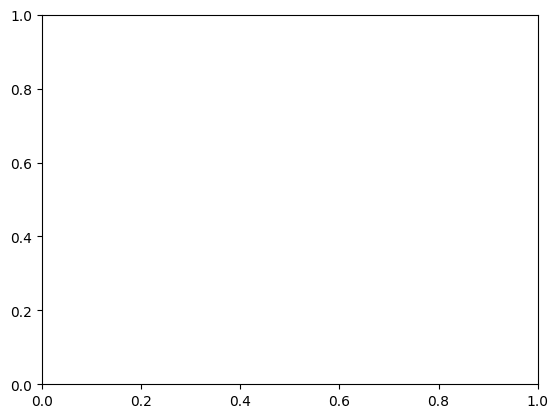

In [3]:
# ============================================================
# EVALUATE JOINT HIERARCHICAL MODEL (bay + stack trained together)
# ACROSS 500 DIFFERENT SEEDS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.joint_hierarchical_policy import MaskableJointTransformerPolicy  # or MaskableJointMlpPolicy

from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
    "vessel_shape": (3, 3, 3),
    "yard_shape": (3, 3, 3),
    "num_containers": 27,
    "group_num": 3,
    "group_placement": "random",
    "observation_type": "stack_features",
    "reward_norm": False,
    "stack_fill_penalty": True
}

JOINT_MODEL_PATH = "models/hierarchical_joint/ppo_hrl_joint_pointer_small_best"  # ← update path
#models\hierarchical_joint\ppo_hrl_joint_pointer_small_best.zip
# ============================================================
# LOAD MODEL
# ============================================================

model = MaskablePPO.load(
    JOINT_MODEL_PATH,
    custom_objects={"policy_class": MaskableJointTransformerPolicy},  # or MaskableJointMlpPolicy
)

print("=" * 70)
print("EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

steps = config_dict["num_containers"]
num_seeds = 500
all_rewards_per_step = np.zeros((num_seeds, steps))
all_rewards = []

for seed in range(num_seeds):
    eval_env = StackEnv(config=config_dict, render_mode=None)
    eval_env = ActionMasker(eval_env, mask_fn)

    obs, info = eval_env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    step_count = 0

    while not (terminated or truncated) and step_count < 200:
        action, _ = model.predict(
            obs,
            deterministic=True,
            action_masks=get_action_masks(eval_env),
        )
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        step_count += 1
        all_rewards_per_step[seed, step_count - 1] = reward

    all_rewards.append(total_reward)
    eval_env.close()

    if (seed + 1) % 50 == 0:
        print(f"Completed {seed + 1}/{num_seeds} seeds...")

# ============================================================
# COMPUTE STATISTICS
# ============================================================

all_rewards = np.array(all_rewards)
mean_reward = np.mean(all_rewards)
std_reward  = np.std(all_rewards)
min_reward  = np.min(all_rewards)
max_reward  = np.max(all_rewards)

percent_max = np.sum(all_rewards > 110) / num_seeds * 100

print(f"Seed with highest reward: {np.argmax(all_rewards)}")
print(f"Seed with lowest reward:  {np.argmin(all_rewards)}")
print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward:.4f}")
print(f"Std Reward:  {std_reward:.4f}")
print(f"Min Reward:  {min_reward:.4f}")
print(f"Max Reward:  {max_reward:.4f}")
print(f"% seeds achieving max reward: {percent_max:.2f}%")
print("=" * 70)

# ============================================================
# DENSITY PLOT
# ============================================================

plt.figure()
plt.hist(all_rewards, bins=30, density=True)
density = gaussian_kde(all_rewards)
xs = np.linspace(all_rewards.min(), all_rewards.max(), 200)
plt.plot(xs, density(xs))
plt.xlabel("Final Episode Reward")
plt.ylabel("Density")
plt.title("Distribution of Rewards — Joint Hierarchical RL (500 Seeds)")
plt.show()

In [5]:
# ============================================================
# LOAD JOINT HIERARCHICAL MODEL + INTERACTIVE VISUAL EVALUATION
# (bay + stack trained jointly in a single model)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.joint_hierarchical_policy import MaskableJointTransformerPolicy
from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
    "vessel_shape": (3, 3, 3),
    "yard_shape": (3, 3, 3),
    "num_containers": 27,
    "group_num": 3,
    "group_placement": "random",
    "observation_type": "stack_features",
    "reward_norm": False,
    "stack_fill_penalty": True
}

JOINT_MODEL_PATH = "models/hierarchical_joint/ppo_hrl_joint_pointer_small_best"

n_rows_per_bay = config_dict["vessel_shape"][1]  # used to derive bay from stack action

# ============================================================
# CREATE ENV + LOAD MODEL
# ============================================================

eval_env = StackEnv(config=config_dict, render_mode="rgb_array")
eval_env = ActionMasker(eval_env, mask_fn)

model = MaskablePPO.load(
    JOINT_MODEL_PATH,
    custom_objects={"policy_class": MaskableJointTransformerPolicy},
)

# ============================================================
# RUN EPISODE & COLLECT FRAMES
# ============================================================

obs, info = eval_env.reset(seed=334)
terminated = False
truncated = False
total_reward = 0.0
step_count = 0

frames = []  # (img, step, stack_action, bay_idx, stack_in_bay, reward, cum_reward)

while not (terminated or truncated) and step_count < 200:
    action, _ = model.predict(
        obs, deterministic=True, action_masks=get_action_masks(eval_env)
    )
    obs, reward, terminated, truncated, info = eval_env.step(action)
    total_reward += reward
    step_count += 1

    img = eval_env.render()
    if img is not None:
        bay_idx = int(action) // n_rows_per_bay
        stack_in_bay = int(action) % n_rows_per_bay
        frames.append((img, step_count, int(action), bay_idx, stack_in_bay, reward, total_reward))

eval_env.close()

print(f"Episode finished: {len(frames)} frames | Total Reward: {total_reward:.4f}")

# ============================================================
# INTERACTIVE VIEWER WIDGET
# ============================================================

slider = widgets.IntSlider(
    value=0, min=0, max=len(frames) - 1, step=1,
    description="Step:", continuous_update=False,
    layout=widgets.Layout(width="60%")
)
prev_btn = widgets.Button(description="◀ Prev", layout=widgets.Layout(width="80px"))
next_btn = widgets.Button(description="Next ▶", layout=widgets.Layout(width="80px"))
info_label = widgets.HTML()
out = widgets.Output()

def show_frame(idx):
    img, step, stack_action, bay_idx, stack_in_bay, reward, cum_reward = frames[idx]
    info_label.value = (
        f"<b>Step {step}/{len(frames)}</b> &nbsp;|&nbsp; "
        f"Stack Action: {stack_action} &nbsp;|&nbsp; "
        f"Bay: {bay_idx} &nbsp;|&nbsp; "
        f"Stack-in-bay: {stack_in_bay} &nbsp;|&nbsp; "
        f"Reward: {reward:.4f} &nbsp;|&nbsp; "
        f"Cumulative: {cum_reward:.4f}"
    )
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.imshow(img)
        ax.set_title(
            f"Step {step} | Stack: {stack_action} | Bay: {bay_idx} | Stack-in-bay: {stack_in_bay} | "
            f"Reward: {reward:.4f} | Total: {cum_reward:.4f}"
        )
        ax.axis("off")
        fig.tight_layout()
        plt.show()

def on_slider_change(change):
    show_frame(change["new"])

def on_prev(b):
    slider.value = max(0, slider.value - 1)

def on_next(b):
    slider.value = min(len(frames) - 1, slider.value + 1)

slider.observe(on_slider_change, names="value")
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

ui = widgets.VBox([
    info_label,
    widgets.HBox([prev_btn, slider, next_btn]),
    out
])

display(ui)
show_frame(0)

Episode finished: 27 frames | Total Reward: 113.4000


Full Joint HRL Medium Testing

EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS
Completed 50/500 seeds...
Completed 100/500 seeds...
Completed 150/500 seeds...
Completed 200/500 seeds...
Completed 250/500 seeds...
Completed 300/500 seeds...
Completed 350/500 seeds...
Completed 400/500 seeds...
Completed 450/500 seeds...
Completed 500/500 seeds...
Seed with highest reward: 1
Seed with lowest reward:  188

EVALUATION RESULTS
Mean Reward: 421.5440
Std Reward:  1.1744
Min Reward:  418.4000
Max Reward:  422.4000
% seeds achieving max reward: 95.00%


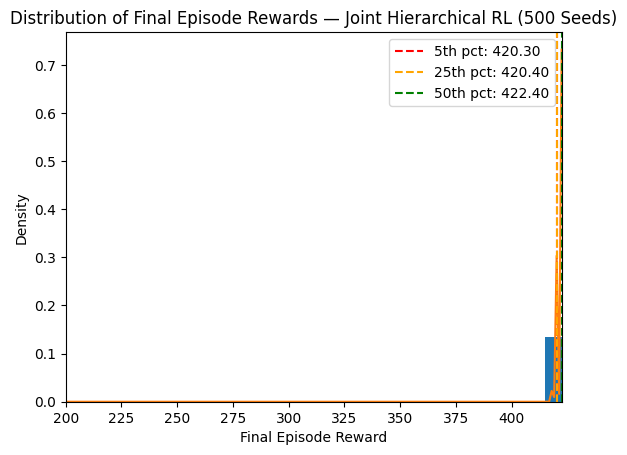

In [5]:
# ============================================================
# EVALUATE JOINT HIERARCHICAL MODEL (bay + stack trained together)
# ACROSS 500 DIFFERENT SEEDS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.joint_hierarchical_policy import MaskableJointTransformerPolicy  # or MaskableJointMlpPolicy

from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
    "vessel_shape": (4, 4, 4),
    "yard_shape": (4, 4, 4),
    "num_containers": 64,
    "group_num": 4,
    "group_placement": "random",
    "observation_type": "stack_features",
    "reward_norm": False,
    "stack_fill_penalty": True
}

JOINT_MODEL_PATH = "models/hierarchical_joint/ppo_hrl_joint_pointer_medium_best"  # ← update path
# ============================================================
# LOAD MODEL
# ============================================================

model = MaskablePPO.load(
    JOINT_MODEL_PATH,
    custom_objects={"policy_class": MaskableJointTransformerPolicy},  # or MaskableJointMlpPolicy
)

print("=" * 70)
print("EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

steps = config_dict["num_containers"]
num_seeds = 500
all_rewards_per_step = np.zeros((num_seeds, steps))
all_rewards = []

for seed in range(num_seeds):
    eval_env = StackEnv(config=config_dict, render_mode=None)
    eval_env = ActionMasker(eval_env, mask_fn)

    obs, info = eval_env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    step_count = 0

    while not (terminated or truncated) and step_count < 200:
        action, _ = model.predict(
            obs,
            deterministic=True,
            action_masks=get_action_masks(eval_env),
        )
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        step_count += 1
        all_rewards_per_step[seed, step_count - 1] = reward

    all_rewards.append(total_reward)
    eval_env.close()

    if (seed + 1) % 50 == 0:
        print(f"Completed {seed + 1}/{num_seeds} seeds...")

# ============================================================
# COMPUTE STATISTICS
# ============================================================

all_rewards = np.array(all_rewards)
mean_reward = np.mean(all_rewards)
std_reward  = np.std(all_rewards)
min_reward  = np.min(all_rewards)
max_reward  = np.max(all_rewards)

percent_max = np.sum(all_rewards > 419) / num_seeds * 100

print(f"Seed with highest reward: {np.argmax(all_rewards)}")
print(f"Seed with lowest reward:  {np.argmin(all_rewards)}")
print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward:.4f}")
print(f"Std Reward:  {std_reward:.4f}")
print(f"Min Reward:  {min_reward:.4f}")
print(f"Max Reward:  {max_reward:.4f}")
print(f"% seeds achieving max reward: {percent_max:.2f}%")
print("=" * 70)

# ============================================================
# DENSITY PLOT
# ============================================================

p5, p25, p50 = np.percentile(all_rewards, [5, 25, 50])

plt.figure()
plt.hist(all_rewards, bins=30, density=True, range=(200, all_rewards.max()))
density = gaussian_kde(all_rewards)
xs = np.linspace(200, all_rewards.max(), 200)
plt.plot(xs, density(xs))

for p, label, color in [(p5, "5th", "red"), (p25, "25th", "orange"), (p50, "50th", "green")]:
    plt.axvline(p, color=color, linestyle="--", label=f"{label} pct: {p:.2f}")

plt.xlim(200, all_rewards.max())
plt.legend()
plt.xlabel("Final Episode Reward")
plt.ylabel("Density")
plt.title("Distribution of Final Episode Rewards — Joint Hierarchical RL (500 Seeds)")
plt.show()

In [ ]:
# ============================================================
# LOAD JOINT HIERARCHICAL MODEL + INTERACTIVE VISUAL EVALUATION
# (bay + stack trained jointly in a single model)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.joint_hierarchical_policy import MaskableJointTransformerPolicy
from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
    "vessel_shape": (4, 4, 4),
    "yard_shape": (4, 4, 4),
    "num_containers": 64,
    "group_num": 4,
    "group_placement": "random",
    "observation_type": "stack_features",
    "reward_norm": False,
    "stack_fill_penalty": True
}

JOINT_MODEL_PATH = "models/hierarchical_joint/ppo_hrl_joint_pointer_medium_best" 

n_rows_per_bay = config_dict["vessel_shape"][1]  # used to derive bay from stack action

# ============================================================
# CREATE ENV + LOAD MODEL
# ============================================================

eval_env = StackEnv(config=config_dict, render_mode="rgb_array")
eval_env = ActionMasker(eval_env, mask_fn)

model = MaskablePPO.load(
    JOINT_MODEL_PATH,
    custom_objects={"policy_class": MaskableJointTransformerPolicy},
)

# ============================================================
# RUN EPISODE & COLLECT FRAMES
# ============================================================

obs, info = eval_env.reset(seed=188)
terminated = False
truncated = False
total_reward = 0.0
step_count = 0

frames = []  # (img, step, stack_action, bay_idx, stack_in_bay, reward, cum_reward)

while not (terminated or truncated) and step_count < 200:
    action, _ = model.predict(
        obs, deterministic=True, action_masks=get_action_masks(eval_env)
    )
    obs, reward, terminated, truncated, info = eval_env.step(action)
    total_reward += reward
    step_count += 1

    img = eval_env.render()
    if img is not None:
        bay_idx = int(action) // n_rows_per_bay
        stack_in_bay = int(action) % n_rows_per_bay
        frames.append((img, step_count, int(action), bay_idx, stack_in_bay, reward, total_reward))

eval_env.close()

print(f"Episode finished: {len(frames)} frames | Total Reward: {total_reward:.4f}")

# ============================================================
# INTERACTIVE VIEWER WIDGET
# ============================================================

slider = widgets.IntSlider(
    value=0, min=0, max=len(frames) - 1, step=1,
    description="Step:", continuous_update=False,
    layout=widgets.Layout(width="60%")
)
prev_btn = widgets.Button(description="◀ Prev", layout=widgets.Layout(width="80px"))
next_btn = widgets.Button(description="Next ▶", layout=widgets.Layout(width="80px"))
info_label = widgets.HTML()
out = widgets.Output()

def show_frame(idx):
    img, step, stack_action, bay_idx, stack_in_bay, reward, cum_reward = frames[idx]
    info_label.value = (
        f"<b>Step {step}/{len(frames)}</b> &nbsp;|&nbsp; "
        f"Stack Action: {stack_action} &nbsp;|&nbsp; "
        f"Bay: {bay_idx} &nbsp;|&nbsp; "
        f"Stack-in-bay: {stack_in_bay} &nbsp;|&nbsp; "
        f"Reward: {reward:.4f} &nbsp;|&nbsp; "
        f"Cumulative: {cum_reward:.4f}"
    )
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(10, 7))
        ax.imshow(img)
        ax.set_title(
            f"Step {step} | Stack: {stack_action} | Bay: {bay_idx} | Stack-in-bay: {stack_in_bay} | "
            f"Reward: {reward:.4f} | Total: {cum_reward:.4f}"
        )
        ax.axis("off")
        fig.tight_layout()
        plt.show()

def on_slider_change(change):
    show_frame(change["new"])

def on_prev(b):
    slider.value = max(0, slider.value - 1)

def on_next(b):
    slider.value = min(len(frames) - 1, slider.value + 1)

slider.observe(on_slider_change, names="value")
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

ui = widgets.VBox([
    info_label,
    widgets.HBox([prev_btn, slider, next_btn]),
    out
])

display(ui)
show_frame(0)

c:\Users\Aritra\rl intern\github\toy_sim\stowage_env\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Episode finished: 64 frames | Total Reward: 418.4000


Fully Joint large yard

In [3]:
# ============================================================
# EVALUATE JOINT HIERARCHICAL MODEL (bay + stack trained together)
# ACROSS 500 DIFFERENT SEEDS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.joint_hierarchical_policy import MaskableJointTransformerPolicy  # or MaskableJointMlpPolicy

from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
    "vessel_shape": (6, 6, 5),
    "yard_shape": (6, 6, 5),
    "num_containers": 180,
    "group_num": 6,
    "group_placement": "random",
    "observation_type": "stack_features",
    "reward_norm": False,
    "stack_fill_penalty": True
}

JOINT_MODEL_PATH = "models/hierarchical_joint/ppo_hrl_joint_pointer_mediumlarge_best"
# ============================================================
# LOAD MODEL
# ============================================================

model = MaskablePPO.load(
    JOINT_MODEL_PATH,
    custom_objects={"policy_class": MaskableJointTransformerPolicy},  # or MaskableJointMlpPolicy
)

print("=" * 70)
print("EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

steps = config_dict["num_containers"]
num_seeds = 200
all_rewards_per_step = np.zeros((num_seeds, steps))
all_rewards = []

for seed in range(num_seeds):
    eval_env = StackEnv(config=config_dict, render_mode=None)
    eval_env = ActionMasker(eval_env, mask_fn)

    obs, info = eval_env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    step_count = 0

    while not (terminated or truncated) and step_count < 500:
        action, _ = model.predict(
            obs,
            deterministic=True,
            action_masks=get_action_masks(eval_env),
        )
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        step_count += 1
        all_rewards_per_step[seed, step_count - 1] = reward

    all_rewards.append(total_reward)
    eval_env.close()

    if (seed + 1) % 25 == 0:
        print(f"Completed {seed + 1}/{num_seeds} seeds...")

# ============================================================
# COMPUTE STATISTICS
# ============================================================

all_rewards = np.array(all_rewards)
mean_reward = np.mean(all_rewards)
std_reward  = np.std(all_rewards)
min_reward  = np.min(all_rewards)
max_reward  = np.max(all_rewards)

percent_max = np.sum(all_rewards > 1700) / num_seeds * 100

print(f"Seed with highest reward: {np.argmax(all_rewards)}")
print(f"Seed with lowest reward:  {np.argmin(all_rewards)}")
print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward:.4f}")
print(f"Std Reward:  {std_reward:.4f}")
print(f"Min Reward:  {min_reward:.4f}")
print(f"Max Reward:  {max_reward:.4f}")
print(f"% seeds achieving max reward: {percent_max:.2f}%")
print("=" * 70)

# ============================================================
# DENSITY PLOT
# ============================================================



EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS
Completed 25/200 seeds...
Completed 50/200 seeds...
Completed 75/200 seeds...
Completed 100/200 seeds...
Completed 125/200 seeds...
Completed 150/200 seeds...
Completed 175/200 seeds...
Completed 200/200 seeds...
Seed with highest reward: 76
Seed with lowest reward:  163

EVALUATION RESULTS
Mean Reward: 1755.3200
Std Reward:  5.5007
Min Reward:  1742.0000
Max Reward:  1770.0000
% seeds achieving max reward: 100.00%


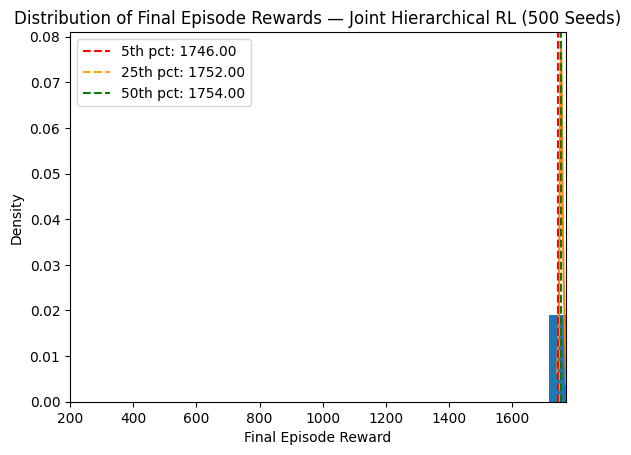

In [4]:
p5, p25, p50 = np.percentile(all_rewards, [5, 25, 50])

plt.figure()
plt.hist(all_rewards, bins=30, density=True, range=(200, all_rewards.max()))
density = gaussian_kde(all_rewards)
xs = np.linspace(all_rewards.min(), all_rewards.max(), 200)
plt.plot(xs, density(xs))

for p, label, color in [(p5, "5th", "red"), (p25, "25th", "orange"), (p50, "50th", "green")]:
    plt.axvline(p, color=color, linestyle="--", label=f"{label} pct: {p:.2f}")

plt.xlim(200, all_rewards.max())
plt.legend()
plt.xlabel("Final Episode Reward")
plt.ylabel("Density")
plt.title("Distribution of Final Episode Rewards — Joint Hierarchical RL (500 Seeds)")
plt.show()

In [ ]:
# ============================================================
# LOAD JOINT HIERARCHICAL MODEL + INTERACTIVE VISUAL EVALUATION
# (bay + stack trained jointly in a single model)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.joint_hierarchical_policy import MaskableJointTransformerPolicy
from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
    "vessel_shape": (6, 6, 5),
    "yard_shape": (6, 6, 5),
    "num_containers": 180,
    "group_num": 6,
    "group_placement": "random",
    "observation_type": "stack_features",
    "reward_norm": False,
    "stack_fill_penalty": True
}

JOINT_MODEL_PATH = "models/hierarchical_joint/ppo_hrl_joint_pointer_mediumlarge_best"
# models\hierarchical_joint\ppo_hrl_joint_pointer_large_t2_big_best.zip 

n_rows_per_bay = config_dict["vessel_shape"][1]  # used to derive bay from stack action

# ============================================================
# CREATE ENV + LOAD MODEL
# ============================================================

eval_env = StackEnv(config=config_dict, render_mode="rgb_array")
eval_env = ActionMasker(eval_env, mask_fn)

model = MaskablePPO.load(
    JOINT_MODEL_PATH,
    custom_objects={"policy_class": MaskableJointTransformerPolicy},
)

# ============================================================
# RUN EPISODE & COLLECT FRAMES
# ============================================================

obs, info = eval_env.reset(seed=163)
terminated = False
truncated = False
total_reward = 0.0
step_count = 0

frames = []  # (img, step, stack_action, bay_idx, stack_in_bay, reward, cum_reward)

while not (terminated or truncated) and step_count < 500:
    action, _ = model.predict(
        obs, deterministic=True, action_masks=get_action_masks(eval_env)
    )
    obs, reward, terminated, truncated, info = eval_env.step(action)
    total_reward += reward
    step_count += 1

    img = eval_env.render()
    if img is not None:
        bay_idx = int(action) // n_rows_per_bay
        stack_in_bay = int(action) % n_rows_per_bay
        frames.append((img, step_count, int(action), bay_idx, stack_in_bay, reward, total_reward))

eval_env.close()

print(f"Episode finished: {len(frames)} frames | Total Reward: {total_reward:.4f}")

# ============================================================
# INTERACTIVE VIEWER WIDGET
# ============================================================

slider = widgets.IntSlider(
    value=0, min=0, max=len(frames) - 1, step=1,
    description="Step:", continuous_update=False,
    layout=widgets.Layout(width="60%")
)
prev_btn = widgets.Button(description="◀ Prev", layout=widgets.Layout(width="80px"))
next_btn = widgets.Button(description="Next ▶", layout=widgets.Layout(width="80px"))
info_label = widgets.HTML()
out = widgets.Output()

def show_frame(idx):
    img, step, stack_action, bay_idx, stack_in_bay, reward, cum_reward = frames[idx]
    info_label.value = (
        f"<b>Step {step}/{len(frames)}</b> &nbsp;|&nbsp; "
        f"Stack Action: {stack_action} &nbsp;|&nbsp; "
        f"Bay: {bay_idx} &nbsp;|&nbsp; "
        f"Stack-in-bay: {stack_in_bay} &nbsp;|&nbsp; "
        f"Reward: {reward:.4f} &nbsp;|&nbsp; "
        f"Cumulative: {cum_reward:.4f}"
    )
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(19, 13))
        ax.imshow(img)
        ax.set_title(
            f"Step {step} | Stack: {stack_action} | Bay: {bay_idx} | Stack-in-bay: {stack_in_bay} | "
            f"Reward: {reward:.4f} | Total: {cum_reward:.4f}"
        )
        ax.axis("off")
        fig.tight_layout()
        plt.show()

def on_slider_change(change):
    show_frame(change["new"])

def on_prev(b):
    slider.value = max(0, slider.value - 1)

def on_next(b):
    slider.value = min(len(frames) - 1, slider.value + 1)

slider.observe(on_slider_change, names="value")
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

ui = widgets.VBox([
    info_label,
    widgets.HBox([prev_btn, slider, next_btn]),
    out
])

display(ui)
show_frame(0)

c:\Users\Aritra\rl intern\github\toy_sim\stowage_env\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Episode finished: 180 frames | Total Reward: 1742.0000


Full Joint HRL Large testing simple obs

EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS
Completed 50/100 seeds...
Completed 100/100 seeds...
Seed with highest reward: 16
Seed with lowest reward:  57

EVALUATION RESULTS
Mean Reward: 4005.9640
Std Reward:  426.4128
Min Reward:  1934.4000
Max Reward:  4286.0000
% seeds achieving max reward: 97.00%


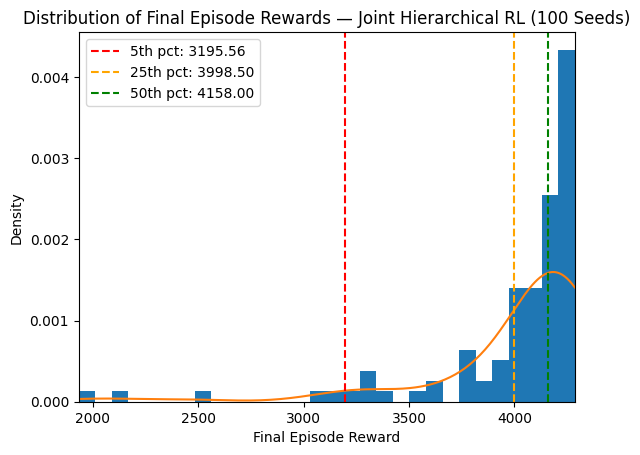

In [12]:
# ============================================================
# EVALUATE JOINT HIERARCHICAL MODEL (bay + stack trained together)
# ACROSS 500 DIFFERENT SEEDS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.joint_hierarchical_policy import MaskableJointTransformerPolicy  # or MaskableJointMlpPolicy

from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
    "vessel_shape": (10, 8, 5),
    "yard_shape": (10, 8, 5),
    "num_containers": 400,
    "group_num": 10,
    "group_placement": "random",
    "observation_type": "stack_features_v3",
    "reward_norm": False,
    "stack_fill_penalty": True
}

JOINT_MODEL_PATH = "models/hierarchical_joint/ppo_hrl_joint_pointer_large4_simpleobs_v2_best" # ← update path
# ============================================================
# LOAD MODEL
# ============================================================

model = MaskablePPO.load(
    JOINT_MODEL_PATH,
    custom_objects={"policy_class": MaskableJointTransformerPolicy},  # or MaskableJointMlpPolicy
)

print("=" * 70)
print("EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

steps = config_dict["num_containers"]
num_seeds = 100
all_rewards_per_step = np.zeros((num_seeds, steps))
all_rewards = []

for seed in range(num_seeds):
    eval_env = StackEnv(config=config_dict, render_mode=None)
    eval_env = ActionMasker(eval_env, mask_fn)

    obs, info = eval_env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    step_count = 0

    while not (terminated or truncated) and step_count < 500:
        action, _ = model.predict(
            obs,
            deterministic=True,
            action_masks=get_action_masks(eval_env),
        )
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        step_count += 1
        all_rewards_per_step[seed, step_count - 1] = reward

    all_rewards.append(total_reward)
    eval_env.close()

    if (seed + 1) % 50 == 0:
        print(f"Completed {seed + 1}/{num_seeds} seeds...")

# ============================================================
# COMPUTE STATISTICS
# ============================================================

all_rewards = np.array(all_rewards)
mean_reward = np.mean(all_rewards)
std_reward  = np.std(all_rewards)
min_reward  = np.min(all_rewards)
max_reward  = np.max(all_rewards)

percent_max = np.sum(all_rewards > 2900) / num_seeds * 100

print(f"Seed with highest reward: {np.argmax(all_rewards)}")
print(f"Seed with lowest reward:  {np.argmin(all_rewards)}")
print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward:.4f}")
print(f"Std Reward:  {std_reward:.4f}")
print(f"Min Reward:  {min_reward:.4f}")
print(f"Max Reward:  {max_reward:.4f}")
print(f"% seeds achieving max reward: {percent_max:.2f}%")
print("=" * 70)

# ============================================================
# DENSITY PLOT
# ============================================================

p5, p25, p50 = np.percentile(all_rewards, [5, 25, 50])

plt.figure()
plt.hist(all_rewards, bins=30, density=True, range=(all_rewards.min(), all_rewards.max()))
density = gaussian_kde(all_rewards)
xs = np.linspace(all_rewards.min(), all_rewards.max(), 200)
plt.plot(xs, density(xs))

for p, label, color in [(p5, "5th", "red"), (p25, "25th", "orange"), (p50, "50th", "green")]:
    plt.axvline(p, color=color, linestyle="--", label=f"{label} pct: {p:.2f}")

plt.xlim(all_rewards.min(), all_rewards.max())
plt.legend()
plt.xlabel("Final Episode Reward")
plt.ylabel("Density")
plt.title("Distribution of Final Episode Rewards — Joint Hierarchical RL (100 Seeds)")
plt.show()

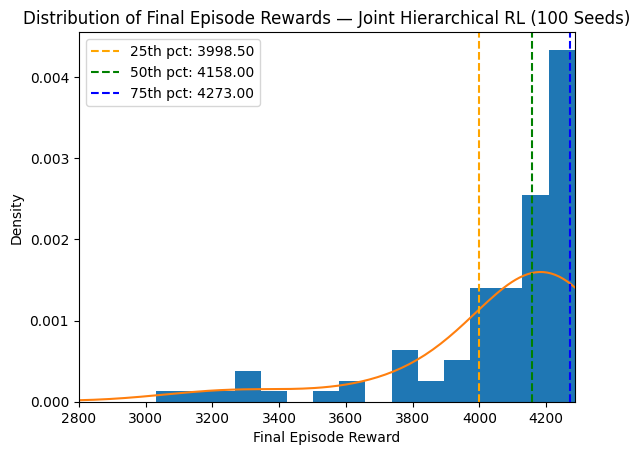

In [13]:
p25, p50, p75 = np.percentile(all_rewards, [25, 50, 75])

plt.figure()
plt.hist(all_rewards, bins=30, density=True, range=(all_rewards.min(), all_rewards.max()))
density = gaussian_kde(all_rewards)
xs = np.linspace(all_rewards.min(), all_rewards.max(), 200)
plt.plot(xs, density(xs))

for p, label, color in [(p25, "25th", "orange"), (p50, "50th", "green"), (p75, "75th", "blue")]:
    plt.axvline(p, color=color, linestyle="--", label=f"{label} pct: {p:.2f}")

plt.xlim(2800, all_rewards.max())
plt.legend()
plt.xlabel("Final Episode Reward")
plt.ylabel("Density")
plt.title("Distribution of Final Episode Rewards — Joint Hierarchical RL (100 Seeds)")
plt.show()

In [ ]:
# ============================================================
# LOAD JOINT HIERARCHICAL MODEL + INTERACTIVE VISUAL EVALUATION
# (bay + stack trained jointly in a single model)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.joint_hierarchical_policy import MaskableJointTransformerPolicy
from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
    "vessel_shape": (10, 8, 5),
    "yard_shape": (10, 8, 5),
    "num_containers": 400,
    "group_num": 10,
    "group_placement": "random",
    "observation_type": "stack_features_v3",
    "reward_norm": False,
    "stack_fill_penalty": True
}

JOINT_MODEL_PATH = "models/hierarchical_joint/ppo_hrl_joint_pointer_large4_simpleobs_v2_best" # ← update path

n_rows_per_bay = config_dict["vessel_shape"][1]  # used to derive bay from stack action

# ============================================================
# CREATE ENV + LOAD MODEL
# ============================================================

eval_env = StackEnv(config=config_dict, render_mode="rgb_array")
eval_env = ActionMasker(eval_env, mask_fn)

model = MaskablePPO.load(
    JOINT_MODEL_PATH,
    custom_objects={"policy_class": MaskableJointTransformerPolicy},
)

# ============================================================
# RUN EPISODE & COLLECT FRAMES
# ============================================================

obs, info = eval_env.reset(seed=25)
terminated = False
truncated = False
total_reward = 0.0
step_count = 0

frames = []  # (img, step, stack_action, bay_idx, stack_in_bay, reward, cum_reward)

while not (terminated or truncated) and step_count < 500:
    action, _ = model.predict(
        obs, deterministic=True, action_masks=get_action_masks(eval_env)
    )
    obs, reward, terminated, truncated, info = eval_env.step(action)
    total_reward += reward
    step_count += 1

    img = eval_env.render()
    if img is not None:
        bay_idx = int(action) // n_rows_per_bay
        stack_in_bay = int(action) % n_rows_per_bay
        frames.append((img, step_count, int(action), bay_idx, stack_in_bay, reward, total_reward))

eval_env.close()

print(f"Episode finished: {len(frames)} frames | Total Reward: {total_reward:.4f}")

# ============================================================
# INTERACTIVE VIEWER WIDGET
# ============================================================

slider = widgets.IntSlider(
    value=0, min=0, max=len(frames) - 1, step=1,
    description="Step:", continuous_update=False,
    layout=widgets.Layout(width="60%")
)
prev_btn = widgets.Button(description="◀ Prev", layout=widgets.Layout(width="80px"))
next_btn = widgets.Button(description="Next ▶", layout=widgets.Layout(width="80px"))
info_label = widgets.HTML()
out = widgets.Output()

def show_frame(idx):
    img, step, stack_action, bay_idx, stack_in_bay, reward, cum_reward = frames[idx]
    info_label.value = (
        f"<b>Step {step}/{len(frames)}</b> &nbsp;|&nbsp; "
        f"Stack Action: {stack_action} &nbsp;|&nbsp; "
        f"Bay: {bay_idx} &nbsp;|&nbsp; "
        f"Stack-in-bay: {stack_in_bay} &nbsp;|&nbsp; "
        f"Reward: {reward:.4f} &nbsp;|&nbsp; "
        f"Cumulative: {cum_reward:.4f}"
    )
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(19, 13))
        ax.imshow(img)
        ax.set_title(
            f"Step {step} | Stack: {stack_action} | Bay: {bay_idx} | Stack-in-bay: {stack_in_bay} | "
            f"Reward: {reward:.4f} | Total: {cum_reward:.4f}"
        )
        ax.axis("off")
        fig.tight_layout()
        plt.show()

def on_slider_change(change):
    show_frame(change["new"])

def on_prev(b):
    slider.value = max(0, slider.value - 1)

def on_next(b):
    slider.value = min(len(frames) - 1, slider.value + 1)

slider.observe(on_slider_change, names="value")
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

ui = widgets.VBox([
    info_label,
    widgets.HBox([prev_btn, slider, next_btn]),
    out
])

display(ui)
show_frame(0)

Episode finished: 400 frames | Total Reward: 4278.0000


Joint HRL with 20/40 feet

EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS
Completed 10/50 seeds...
Completed 20/50 seeds...
Completed 30/50 seeds...
Completed 40/50 seeds...
Completed 50/50 seeds...
Seed with highest reward: 13
Seed with lowest reward:  12

EVALUATION RESULTS
Mean Reward: 4107.7720
Std Reward:  215.4899
Min Reward:  2917.8000
Max Reward:  4235.2000
% seeds achieving max reward: 88.00%


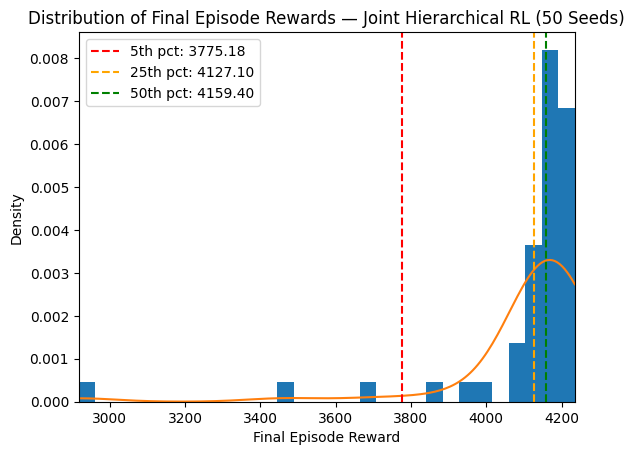

In [2]:
# ============================================================
# EVALUATE JOINT HIERARCHICAL MODEL (bay + stack trained together)
# ACROSS 500 DIFFERENT SEEDS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.joint_hierarchical_policy import MaskableJointTransformerPolicy  # or MaskableJointMlpPolicy

from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
    "vessel_shape": (10, 8, 5),
    "yard_shape": (10, 9, 5),
    "num_containers": 400,
    "group_num": 10,
    "group_placement": "random",
    "observation_type": "stack_features_v3",
    "reward_norm": False,
    "stack_fill_penalty": True,
    "container_sizes": True
}

JOINT_MODEL_PATH = "models/hierarchical_joint/ppo_hrl_joint_pointer_large4_simpleobs_40ft_alt/best_model"
# ============================================================
# LOAD MODEL
# ============================================================

model = MaskablePPO.load(
    JOINT_MODEL_PATH,
    custom_objects={"policy_class": MaskableJointTransformerPolicy},  # or MaskableJointMlpPolicy
)

print("=" * 70)
print("EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

steps = config_dict["num_containers"]
num_seeds = 50
all_rewards_per_step = np.zeros((num_seeds, steps))
all_rewards = []

for seed in range(num_seeds):
    eval_env = StackEnv(config=config_dict, render_mode=None)
    eval_env = ActionMasker(eval_env, mask_fn)

    obs, info = eval_env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    step_count = 0

    while not (terminated or truncated) and step_count < 500:
        action, _ = model.predict(
            obs,
            deterministic=True,
            action_masks=get_action_masks(eval_env),
        )
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        step_count += 1
        all_rewards_per_step[seed, step_count - 1] = reward

    all_rewards.append(total_reward)
    eval_env.close()

    if (seed + 1) % 10 == 0:
        print(f"Completed {seed + 1}/{num_seeds} seeds...")

# ============================================================
# COMPUTE STATISTICS
# ============================================================

all_rewards = np.array(all_rewards)
mean_reward = np.mean(all_rewards)
std_reward  = np.std(all_rewards)
min_reward  = np.min(all_rewards)
max_reward  = np.max(all_rewards)

percent_max = np.sum(all_rewards > 4060) / num_seeds * 100

print(f"Seed with highest reward: {np.argmax(all_rewards)}")
print(f"Seed with lowest reward:  {np.argmin(all_rewards)}")
print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward:.4f}")
print(f"Std Reward:  {std_reward:.4f}")
print(f"Min Reward:  {min_reward:.4f}")
print(f"Max Reward:  {max_reward:.4f}")
print(f"% seeds achieving max reward: {percent_max:.2f}%")
print("=" * 70)

# ============================================================
# DENSITY PLOT
# ============================================================

p5, p25, p50 = np.percentile(all_rewards, [5, 25, 50])

plt.figure()
plt.hist(all_rewards, bins=30, density=True, range=(all_rewards.min(), all_rewards.max()))
density = gaussian_kde(all_rewards)
xs = np.linspace(all_rewards.min(), all_rewards.max(), 200)
plt.plot(xs, density(xs))

for p, label, color in [(p5, "5th", "red"), (p25, "25th", "orange"), (p50, "50th", "green")]:
    plt.axvline(p, color=color, linestyle="--", label=f"{label} pct: {p:.2f}")

plt.xlim(all_rewards.min(), all_rewards.max())
plt.legend()
plt.xlabel("Final Episode Reward")
plt.ylabel("Density")
plt.title("Distribution of Final Episode Rewards — Joint Hierarchical RL (50 Seeds)")
plt.show()

Text(0.5, 0, 'Final Episode Reward')

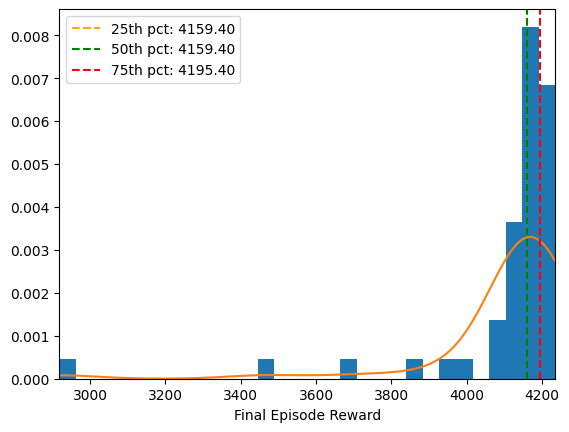

In [3]:
p5, p25, p75 = np.percentile(all_rewards, [25, 50, 75])

plt.figure()
plt.hist(all_rewards, bins=30, density=True, range=(all_rewards.min(), all_rewards.max()))
density = gaussian_kde(all_rewards)
xs = np.linspace(all_rewards.min(), all_rewards.max(), 200)
plt.plot(xs, density(xs))

for p, label, color in [(p25, "25th", "orange"), (p50, "50th", "green"),(p75, "75th", "red")]:
    plt.axvline(p, color=color, linestyle="--", label=f"{label} pct: {p:.2f}")

plt.xlim(all_rewards.min(), all_rewards.max())
plt.legend()
plt.xlabel("Final Episode Reward")

In [ ]:
# ============================================================
# LOAD JOINT HIERARCHICAL MODEL + INTERACTIVE VISUAL EVALUATION
# (bay + stack trained jointly in a single model)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.joint_hierarchical_policy import MaskableJointTransformerPolicy
from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = {
    "vessel_shape": (10, 8, 5),
    "yard_shape": (10, 9, 5),
    "num_containers": 400,
    "group_num": 10,
    "group_placement": "random",
    "observation_type": "stack_features_v3",
    "reward_norm": False,
    "stack_fill_penalty": True,
    "container_sizes": True
}

JOINT_MODEL_PATH = "models/hierarchical_joint/ppo_hrl_joint_pointer_large4_simpleobs_40ft_alt/best_model"  # ← update path
n_rows_per_bay = config_dict["vessel_shape"][1]  # used to derive bay from stack action

# ============================================================
# CREATE ENV + LOAD MODEL
# ============================================================

eval_env = StackEnv(config=config_dict, render_mode="rgb_array")
eval_env = ActionMasker(eval_env, mask_fn)

model = MaskablePPO.load(
    JOINT_MODEL_PATH,
    custom_objects={"policy_class": MaskableJointTransformerPolicy},
)

# ============================================================
# RUN EPISODE & COLLECT FRAMES
# ============================================================

obs, info = eval_env.reset(seed=19)
terminated = False
truncated = False
total_reward = 0.0
step_count = 0

frames = []  # (img, step, stack_action, bay_idx, stack_in_bay, reward, cum_reward)

while not (terminated or truncated) and step_count < 500:
    action, _ = model.predict(
        obs, deterministic=True, action_masks=get_action_masks(eval_env)
    )
    obs, reward, terminated, truncated, info = eval_env.step(action)
    total_reward += reward
    step_count += 1

    img = eval_env.render()
    if img is not None:
        bay_idx = int(action) // n_rows_per_bay
        stack_in_bay = int(action) % n_rows_per_bay
        frames.append((img, step_count, int(action), bay_idx, stack_in_bay, reward, total_reward))

eval_env.close()

print(f"Episode finished: {len(frames)} frames | Total Reward: {total_reward:.4f}")

# ============================================================
# INTERACTIVE VIEWER WIDGET
# ============================================================

slider = widgets.IntSlider(
    value=0, min=0, max=len(frames) - 1, step=1,
    description="Step:", continuous_update=False,
    layout=widgets.Layout(width="60%")
)
prev_btn = widgets.Button(description="◀ Prev", layout=widgets.Layout(width="80px"))
next_btn = widgets.Button(description="Next ▶", layout=widgets.Layout(width="80px"))
info_label = widgets.HTML()
out = widgets.Output()

def show_frame(idx):
    img, step, stack_action, bay_idx, stack_in_bay, reward, cum_reward = frames[idx]
    info_label.value = (
        f"<b>Step {step}/{len(frames)}</b> &nbsp;|&nbsp; "
        f"Stack Action: {stack_action} &nbsp;|&nbsp; "
        f"Bay: {bay_idx} &nbsp;|&nbsp; "
        f"Stack-in-bay: {stack_in_bay} &nbsp;|&nbsp; "
        f"Reward: {reward:.4f} &nbsp;|&nbsp; "
        f"Cumulative: {cum_reward:.4f}"
    )
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(19, 13))
        ax.imshow(img)
        ax.set_title(
            f"Step {step} | Stack: {stack_action} | Bay: {bay_idx} | Stack-in-bay: {stack_in_bay} | "
            f"Reward: {reward:.4f} | Total: {cum_reward:.4f}"
        )
        ax.axis("off")
        fig.tight_layout()
        plt.show()

def on_slider_change(change):
    show_frame(change["new"])

def on_prev(b):
    slider.value = max(0, slider.value - 1)

def on_next(b):
    slider.value = min(len(frames) - 1, slider.value + 1)

slider.observe(on_slider_change, names="value")
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

ui = widgets.VBox([
    info_label,
    widgets.HBox([prev_btn, slider, next_btn]),
    out
])

display(ui)
show_frame(0)

Episode finished: 400 frames | Total Reward: 4182.8000


Joint HRL with 20/40 feet and IMO

EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS
Completed 10/50 seeds...
Completed 20/50 seeds...
Completed 30/50 seeds...
Completed 40/50 seeds...
Completed 50/50 seeds...
Seed with highest reward: 28
Seed with lowest reward:  30

EVALUATION RESULTS
Mean Reward: 3951.3520
Std Reward:  140.1656
Min Reward:  3522.4000
Max Reward:  4216.0000
% seeds achieving max reward: 82.00%


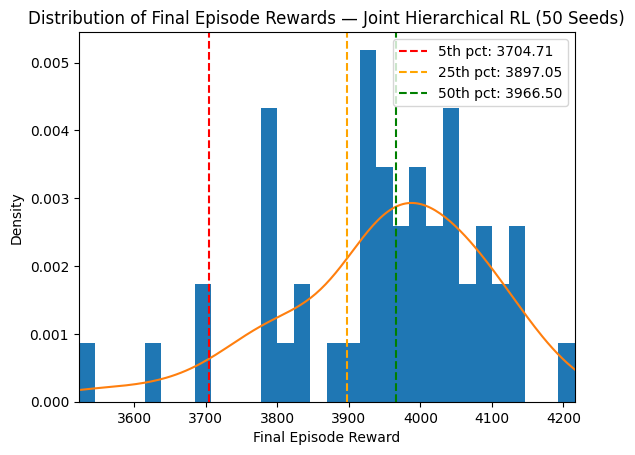

In [2]:
# ============================================================
# EVALUATE JOINT HIERARCHICAL MODEL (bay + stack trained together)
# ACROSS 500 DIFFERENT SEEDS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.joint_hierarchical_policy import MaskableJointTransformerPolicy  # or MaskableJointMlpPolicy

from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================


config_dict = config = {
            "vessel_shape": (10, 8, 5),
            "yard_shape": (10, 9, 5),
            "num_containers": 400,
            "group_num": 10,
            "group_placement": "random",
            "observation_type": "stack_features_v3",
            "reward_norm": False,
            "reward_clip": False,
            "stack_fill_penalty": True,
            "container_sizes": True,
            "enable_imo": True,
            "random_group_sizes": True
        }

JOINT_MODEL_PATH = "models/hierarchical_joint/ppo_hrl_joint_pointer_large4_simpleobs_imo_rc/best_model" # ← update path
# ============================================================
# LOAD MODEL
# ============================================================

model = MaskablePPO.load(
    JOINT_MODEL_PATH,
    custom_objects={"policy_class": MaskableJointTransformerPolicy},  # or MaskableJointMlpPolicy
)

print("=" * 70)
print("EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

steps = config_dict["num_containers"]
num_seeds = 50
all_rewards_per_step = np.zeros((num_seeds, steps))
all_rewards = []

for seed in range(num_seeds):
    eval_env = StackEnv(config=config_dict, render_mode=None)
    eval_env = ActionMasker(eval_env, mask_fn)

    obs, info = eval_env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    step_count = 0

    while not (terminated or truncated) and step_count < 500:
        action, _ = model.predict(
            obs,
            deterministic=True,
            action_masks=get_action_masks(eval_env),
        )
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        step_count += 1
        all_rewards_per_step[seed, step_count - 1] = reward

    all_rewards.append(total_reward)
    eval_env.close()

    if (seed + 1) % 10 == 0:
        print(f"Completed {seed + 1}/{num_seeds} seeds...")

# ============================================================
# COMPUTE STATISTICS
# ============================================================

all_rewards = np.array(all_rewards)
mean_reward = np.mean(all_rewards)
std_reward  = np.std(all_rewards)
min_reward  = np.min(all_rewards)
max_reward  = np.max(all_rewards)

percent_max = np.sum(all_rewards > 3800) / num_seeds * 100

print(f"Seed with highest reward: {np.argmax(all_rewards)}")
print(f"Seed with lowest reward:  {np.argmin(all_rewards)}")
print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward:.4f}")
print(f"Std Reward:  {std_reward:.4f}")
print(f"Min Reward:  {min_reward:.4f}")
print(f"Max Reward:  {max_reward:.4f}")
print(f"% seeds achieving max reward: {percent_max:.2f}%")
print("=" * 70)

# ============================================================
# DENSITY PLOT
# ============================================================

p5, p25, p50 = np.percentile(all_rewards, [5, 25, 50])

plt.figure()
plt.hist(all_rewards, bins=30, density=True, range=(all_rewards.min(), all_rewards.max()))
density = gaussian_kde(all_rewards)
xs = np.linspace(all_rewards.min(), all_rewards.max(), 200)
plt.plot(xs, density(xs))

for p, label, color in [(p5, "5th", "red"), (p25, "25th", "orange"), (p50, "50th", "green")]:
    plt.axvline(p, color=color, linestyle="--", label=f"{label} pct: {p:.2f}")

plt.xlim(all_rewards.min(), all_rewards.max())
plt.legend()
plt.xlabel("Final Episode Reward")
plt.ylabel("Density")
plt.title("Distribution of Final Episode Rewards — Joint Hierarchical RL (50 Seeds)")
plt.show()

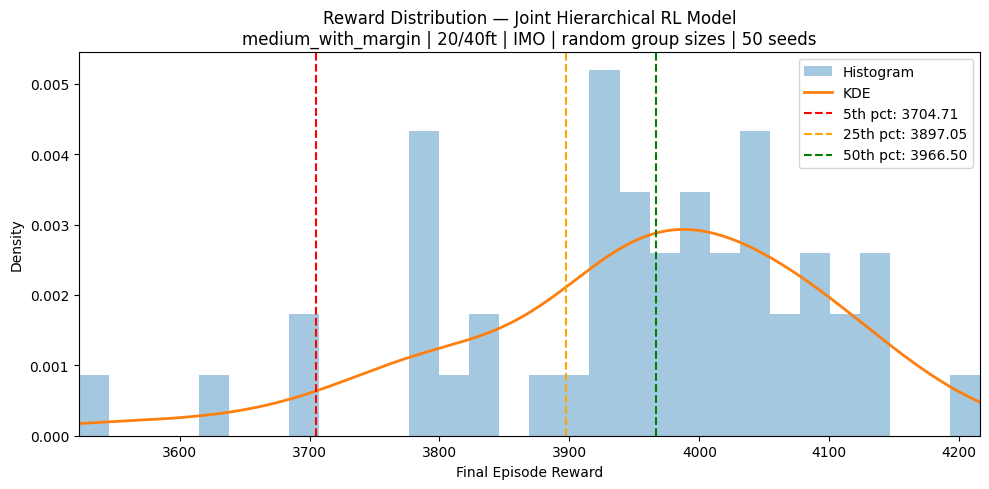

In [13]:
# ============================================================
# DENSITY PLOT
# ============================================================

p5, p25, p50 = np.percentile(all_rewards, [5, 25, 50])

plt.figure(figsize=(10, 5))
plt.hist(all_rewards, bins=30, density=True, alpha=0.4,
         range=(all_rewards.min(), all_rewards.max()), label="Histogram")
density = gaussian_kde(all_rewards)
xs = np.linspace(all_rewards.min(), all_rewards.max(), 300)
plt.plot(xs, density(xs), linewidth=2, label="KDE")

for p, label, color in [(p5, "5th", "red"), (p25, "25th", "orange"), (p50, "50th", "green")]:
    plt.axvline(p, color=color, linestyle="--", label=f"{label} pct: {p:.2f}")

plt.xlim(all_rewards.min(), all_rewards.max())
plt.legend()
plt.xlabel("Final Episode Reward")
plt.ylabel("Density")
plt.title(
    f"Reward Distribution — Joint Hierarchical RL Model\n"
    f"medium_with_margin | 20/40ft | IMO | random group sizes | {num_seeds} seeds"
)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# LOAD JOINT HIERARCHICAL MODEL + INTERACTIVE VISUAL EVALUATION
# (bay + stack trained jointly in a single model)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.joint_hierarchical_policy import MaskableJointTransformerPolicy
from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = config = {
            "vessel_shape": (10, 8, 5),
            "yard_shape": (10, 9, 5),
            "num_containers": 400,
            "group_num": 10,
            "group_placement": "random",
            "observation_type": "stack_features_v3",
            "reward_norm": False,
            "reward_clip": False,
            "stack_fill_penalty": True,
            "container_sizes": True,
            "enable_imo": True,
            "random_group_sizes": True
        }

JOINT_MODEL_PATH = "models/hierarchical_joint/ppo_hrl_joint_pointer_large4_simpleobs_imo_rc/best_model" # ← update path
n_rows_per_bay = config_dict["yard_shape"][1]  # used to derive bay from stack action

# ============================================================
# CREATE ENV + LOAD MODEL
# ============================================================

eval_env = StackEnv(config=config_dict, render_mode="rgb_array")
eval_env = ActionMasker(eval_env, mask_fn)

model = MaskablePPO.load(
    JOINT_MODEL_PATH,
    custom_objects={"policy_class": MaskableJointTransformerPolicy},
)

# ============================================================
# RUN EPISODE & COLLECT FRAMES
# ============================================================

obs, info = eval_env.reset(seed=21)
terminated = False
truncated = False
total_reward = 0.0
step_count = 0

frames = []  # (img, step, stack_action, bay_idx, stack_in_bay, reward, cum_reward)

while not (terminated or truncated) and step_count < 500:
    action, _ = model.predict(
        obs, deterministic=True, action_masks=get_action_masks(eval_env)
    )
    obs, reward, terminated, truncated, info = eval_env.step(action)
    total_reward += reward
    step_count += 1

    img = eval_env.render()
    if img is not None:
        bay_idx = int(action) // n_rows_per_bay
        stack_in_bay = int(action) % n_rows_per_bay
        frames.append((img, step_count, int(action), bay_idx, stack_in_bay, reward, total_reward))

eval_env.close()

print(f"Episode finished: {len(frames)} frames | Total Reward: {total_reward:.4f}")

# ============================================================
# INTERACTIVE VIEWER WIDGET
# ============================================================

slider = widgets.IntSlider(
    value=0, min=0, max=len(frames) - 1, step=1,
    description="Step:", continuous_update=False,
    layout=widgets.Layout(width="60%")
)
prev_btn = widgets.Button(description="◀ Prev", layout=widgets.Layout(width="80px"))
next_btn = widgets.Button(description="Next ▶", layout=widgets.Layout(width="80px"))
info_label = widgets.HTML()
out = widgets.Output()

def show_frame(idx):
    img, step, stack_action, bay_idx, stack_in_bay, reward, cum_reward = frames[idx]
    info_label.value = (
        f"<b>Step {step}/{len(frames)}</b> &nbsp;|&nbsp; "
        f"Stack Action: {stack_action} &nbsp;|&nbsp; "
        f"Bay: {bay_idx} &nbsp;|&nbsp; "
        f"Stack-in-bay: {stack_in_bay} &nbsp;|&nbsp; "
        f"Reward: {reward:.4f} &nbsp;|&nbsp; "
        f"Cumulative: {cum_reward:.4f}"
    )
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(19, 13))
        ax.imshow(img)
        ax.set_title(
            f"Step {step} | Stack: {stack_action} | Bay: {bay_idx} | Stack-in-bay: {stack_in_bay} | "
            f"Reward: {reward:.4f} | Total: {cum_reward:.4f}"
        )
        ax.axis("off")
        fig.tight_layout()
        plt.show()

def on_slider_change(change):
    show_frame(change["new"])

def on_prev(b):
    slider.value = max(0, slider.value - 1)

def on_next(b):
    slider.value = min(len(frames) - 1, slider.value + 1)

slider.observe(on_slider_change, names="value")
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

ui = widgets.VBox([
    info_label,
    widgets.HBox([prev_btn, slider, next_btn]),
    out
])

display(ui)
show_frame(0)

c:\Users\Aritra\rl intern\github\toy_sim\stowage_env\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Episode finished: 400 frames | Total Reward: 3615.2000


EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS
Completed 10/50 seeds...
Completed 20/50 seeds...
Completed 30/50 seeds...
Completed 40/50 seeds...
Completed 50/50 seeds...
Seed with highest reward: 28
Seed with lowest reward:  30

EVALUATION RESULTS
Mean Reward: 3951.3520
Std Reward:  140.1656
Min Reward:  3522.4000
Max Reward:  4216.0000
% seeds achieving max reward: 82.00%


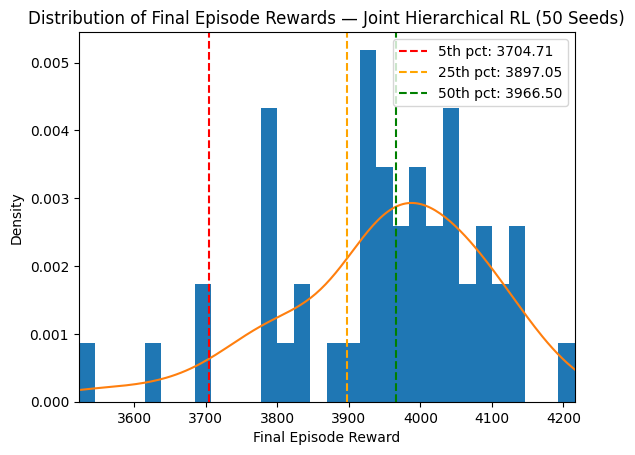

In [2]:
# ============================================================
# EVALUATE JOINT HIERARCHICAL MODEL (bay + stack trained together)
# ACROSS 500 DIFFERENT SEEDS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.joint_hierarchical_policy import MaskableJointTransformerPolicy  # or MaskableJointMlpPolicy

from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================


config_dict = config = {
            "vessel_shape": (10, 8, 5),
            "yard_shape": (10, 9, 5),
            "num_containers": 400,
            "group_num": 10,
            "group_placement": "random",
            "observation_type": "stack_features_v3",
            "reward_norm": False,
            "reward_clip": False,
            "stack_fill_penalty": True,
            "container_sizes": True,
            "enable_imo": True,
            "random_group_sizes": True
        }

JOINT_MODEL_PATH = "models/hierarchical_joint/ppo_hrl_joint_pointer_large4_simpleobs_imo_rc/best_model" # ← update path
# ============================================================
# LOAD MODEL
# ============================================================

model = MaskablePPO.load(
    JOINT_MODEL_PATH,
    custom_objects={"policy_class": MaskableJointTransformerPolicy},  # or MaskableJointMlpPolicy
)

print("=" * 70)
print("EVALUATING JOINT HIERARCHICAL RL MODEL ACROSS 500 SEEDS")
print("=" * 70)

# ============================================================
# RUN 500 EPISODES WITH DIFFERENT SEEDS
# ============================================================

steps = config_dict["num_containers"]
num_seeds = 50
all_rewards_per_step = np.zeros((num_seeds, steps))
all_rewards = []

for seed in range(num_seeds):
    eval_env = StackEnv(config=config_dict, render_mode=None)
    eval_env = ActionMasker(eval_env, mask_fn)

    obs, info = eval_env.reset(seed=seed)
    terminated = False
    truncated = False
    total_reward = 0.0
    step_count = 0

    while not (terminated or truncated) and step_count < 500:
        action, _ = model.predict(
            obs,
            deterministic=True,
            action_masks=get_action_masks(eval_env),
        )
        obs, reward, terminated, truncated, info = eval_env.step(action)
        total_reward += reward
        step_count += 1
        all_rewards_per_step[seed, step_count - 1] = reward

    all_rewards.append(total_reward)
    eval_env.close()

    if (seed + 1) % 10 == 0:
        print(f"Completed {seed + 1}/{num_seeds} seeds...")

# ============================================================
# COMPUTE STATISTICS
# ============================================================

all_rewards = np.array(all_rewards)
mean_reward = np.mean(all_rewards)
std_reward  = np.std(all_rewards)
min_reward  = np.min(all_rewards)
max_reward  = np.max(all_rewards)

percent_max = np.sum(all_rewards > 3800) / num_seeds * 100

print(f"Seed with highest reward: {np.argmax(all_rewards)}")
print(f"Seed with lowest reward:  {np.argmin(all_rewards)}")
print("\n" + "=" * 70)
print("EVALUATION RESULTS")
print("=" * 70)
print(f"Mean Reward: {mean_reward:.4f}")
print(f"Std Reward:  {std_reward:.4f}")
print(f"Min Reward:  {min_reward:.4f}")
print(f"Max Reward:  {max_reward:.4f}")
print(f"% seeds achieving max reward: {percent_max:.2f}%")
print("=" * 70)

# ============================================================
# DENSITY PLOT
# ============================================================

p5, p25, p50 = np.percentile(all_rewards, [5, 25, 50])

plt.figure()
plt.hist(all_rewards, bins=30, density=True, range=(all_rewards.min(), all_rewards.max()))
density = gaussian_kde(all_rewards)
xs = np.linspace(all_rewards.min(), all_rewards.max(), 200)
plt.plot(xs, density(xs))

for p, label, color in [(p5, "5th", "red"), (p25, "25th", "orange"), (p50, "50th", "green")]:
    plt.axvline(p, color=color, linestyle="--", label=f"{label} pct: {p:.2f}")

plt.xlim(all_rewards.min(), all_rewards.max())
plt.legend()
plt.xlabel("Final Episode Reward")
plt.ylabel("Density")
plt.title("Distribution of Final Episode Rewards — Joint Hierarchical RL (50 Seeds)")
plt.show()

In [11]:
# ============================================================
# LOAD JOINT HIERARCHICAL MODEL + INTERACTIVE VISUAL EVALUATION
# (bay + stack trained jointly in a single model)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

from sb3_contrib.ppo_mask import MaskablePPO
from sb3_contrib.common.maskable.utils import get_action_masks
from sb3_contrib.common.wrappers import ActionMasker
from utils import mask_fn
from models.joint_hierarchical_policy import MaskableJointTransformerPolicy
from envs.stack_gym import StackEnv

# ============================================================
# CONFIG (must match training config exactly)
# ============================================================

config_dict = config = {
            "vessel_shape": (10, 8, 5),
            "yard_shape": (10, 9, 5),
            "num_containers": 400,
            "group_num": 10,
            "group_placement": "random",
            "observation_type": "stack_features_v3",
            "reward_norm": False,
            "reward_clip": False,
            "stack_fill_penalty": True,
            "container_sizes": True,
            "enable_imo": True,
            "random_group_sizes": True
        }

JOINT_MODEL_PATH = "models/hierarchical_joint/ppo_hrl_joint_pointer_large4_simpleobs_imo_rc/best_model" # ← update path
n_rows_per_bay = config_dict["yard_shape"][1]  # used to derive bay from stack action

# ============================================================
# CREATE ENV + LOAD MODEL
# ============================================================

eval_env = StackEnv(config=config_dict, render_mode="rgb_array")
eval_env = ActionMasker(eval_env, mask_fn)

model = MaskablePPO.load(
    JOINT_MODEL_PATH,
    custom_objects={"policy_class": MaskableJointTransformerPolicy},
)

# ============================================================
# RUN EPISODE & COLLECT FRAMES
# ============================================================

obs, info = eval_env.reset(seed=30)
terminated = False
truncated = False
total_reward = 0.0
step_count = 0

frames = []  # (img, step, stack_action, bay_idx, stack_in_bay, reward, cum_reward)

while not (terminated or truncated) and step_count < 500:
    action, _ = model.predict(
        obs, deterministic=True, action_masks=get_action_masks(eval_env)
    )
    obs, reward, terminated, truncated, info = eval_env.step(action)
    total_reward += reward
    step_count += 1

    img = eval_env.render()
    if img is not None:
        bay_idx = int(action) // n_rows_per_bay
        stack_in_bay = int(action) % n_rows_per_bay
        frames.append((img, step_count, int(action), bay_idx, stack_in_bay, reward, total_reward))

eval_env.close()

print(f"Episode finished: {len(frames)} frames | Total Reward: {total_reward:.4f}")

# ============================================================
# INTERACTIVE VIEWER WIDGET
# ============================================================

slider = widgets.IntSlider(
    value=0, min=0, max=len(frames) - 1, step=1,
    description="Step:", continuous_update=False,
    layout=widgets.Layout(width="60%")
)
prev_btn = widgets.Button(description="◀ Prev", layout=widgets.Layout(width="80px"))
next_btn = widgets.Button(description="Next ▶", layout=widgets.Layout(width="80px"))
info_label = widgets.HTML()
out = widgets.Output()

def show_frame(idx):
    img, step, stack_action, bay_idx, stack_in_bay, reward, cum_reward = frames[idx]
    info_label.value = (
        f"<b>Step {step}/{len(frames)}</b> &nbsp;|&nbsp; "
        f"Stack Action: {stack_action} &nbsp;|&nbsp; "
        f"Bay: {bay_idx} &nbsp;|&nbsp; "
        f"Stack-in-bay: {stack_in_bay} &nbsp;|&nbsp; "
        f"Reward: {reward:.4f} &nbsp;|&nbsp; "
        f"Cumulative: {cum_reward:.4f}"
    )
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(19, 13))
        ax.imshow(img)
        ax.set_title(
            f"Step {step} | Stack: {stack_action} | Bay: {bay_idx} | Stack-in-bay: {stack_in_bay} | "
            f"Reward: {reward:.4f} | Total: {cum_reward:.4f}"
        )
        ax.axis("off")
        fig.tight_layout()
        plt.show()

def on_slider_change(change):
    show_frame(change["new"])

def on_prev(b):
    slider.value = max(0, slider.value - 1)

def on_next(b):
    slider.value = min(len(frames) - 1, slider.value + 1)

slider.observe(on_slider_change, names="value")
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)

ui = widgets.VBox([
    info_label,
    widgets.HBox([prev_btn, slider, next_btn]),
    out
])

display(ui)
show_frame(0)

Episode finished: 400 frames | Total Reward: 3522.4000


In [12]:
# ============================================================
# INTERACTIVE VIEWER WIDGET (with Save Button)
# ============================================================

slider = widgets.IntSlider(
    value=0, min=0, max=len(frames) - 1, step=1,
    description="Step:", continuous_update=False,
    layout=widgets.Layout(width="60%")
)
prev_btn = widgets.Button(description="◀ Prev", layout=widgets.Layout(width="80px"))
next_btn = widgets.Button(description="Next ▶", layout=widgets.Layout(width="80px"))
save_btn = widgets.Button(description="💾 Save", layout=widgets.Layout(width="80px"), button_style="info")
info_label = widgets.HTML()
out = widgets.Output()
save_status = widgets.HTML()

def save_current_frame(idx):
    img, step, stack_action, bay_idx, stack_in_bay, reward, cum_reward = frames[idx]
    import os
    os.makedirs("saved_eval_frames", exist_ok=True)
    
    fig, ax = plt.subplots(figsize=(19, 13))
    ax.imshow(img)
    ax.set_title(
        f"Step {step} | Stack: {stack_action} | Bay: {bay_idx} | Stack-in-bay: {stack_in_bay} | "
        f"Reward: {reward:.4f} | Total: {cum_reward:.4f}"
    )
    ax.axis("off")
    fig.tight_layout()
    
    save_path = f"saved_eval_frames/hrl/episode_step_{step}.png"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=100, bbox_inches="tight")
    plt.close(fig)
    
    save_status.value = f'<span style="color:green;"><b>✓ Saved to {save_path}</b></span>'

def show_frame(idx):
    img, step, stack_action, bay_idx, stack_in_bay, reward, cum_reward = frames[idx]
    info_label.value = (
        f"<b>Step {step}/{len(frames)}</b> &nbsp;|&nbsp; "
        f"Stack Action: {stack_action} &nbsp;|&nbsp; "
        f"Bay: {bay_idx} &nbsp;|&nbsp; "
        f"Stack-in-bay: {stack_in_bay} &nbsp;|&nbsp; "
        f"Reward: {reward:.4f} &nbsp;|&nbsp; "
        f"Cumulative: {cum_reward:.4f}"
    )
    save_status.value = ""  # Clear save status on frame change
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(19, 13))
        ax.imshow(img)
        ax.set_title(
            f"Step {step} | Stack: {stack_action} | Bay: {bay_idx} | Stack-in-bay: {stack_in_bay} | "
            f"Reward: {reward:.4f} | Total: {cum_reward:.4f}"
        )
        ax.axis("off")
        fig.tight_layout()
        plt.show()

def on_slider_change(change):
    show_frame(change["new"])

def on_prev(b):
    slider.value = max(0, slider.value - 1)

def on_next(b):
    slider.value = min(len(frames) - 1, slider.value + 1)

def on_save(b):
    save_current_frame(slider.value)

slider.observe(on_slider_change, names="value")
prev_btn.on_click(on_prev)
next_btn.on_click(on_next)
save_btn.on_click(on_save)

ui = widgets.VBox([
    info_label,
    widgets.HBox([prev_btn, slider, next_btn, save_btn]),
    save_status,
    out
])

display(ui)
show_frame(0)